# 청약 가점 예측 프로젝트 — 메인 파이프라인

각 단계별 노트북을 순서대로 실행하거나, 이 노트북에서 전체 파이프라인을 통합 실행합니다.

---
## 일정 정보 컬럼 드랍

> **드랍 이유**: 아래 컬럼들은 공고 *이후*에 확정되는 날짜 정보입니다.  
> 모델은 **공고 전 시점**의 정보만으로 가점 커트라인을 예측해야 하므로 제거합니다.  
> `MVN_PREARNGE_YM`은 `feature_engineering()`에서 `MONTHS_TO_MOVE`로 변환 후 드랍합니다.

## 질문 정리

- 주택명 - 대기업 건설사의 이름이 들어간 경우 최저 가점이 높아지는가? 사람들의 대기업 선호도를 피처로 만들 수 있는가?
- 주택형 - 평수가 올라갈수록 가점이 높아지는가? 아니면 상관이 없을까
- 평형 내 세부 모델 - 모델에 따라 사람들의 선호도가 달라지고 이것이 가점을 높일 수 있을까? 평형에 따른 선호도를 피처로 만들 수 있는가?
- 경쟁률 : 사전에 알 수 있는 정보임을 확인 - 경쟁률에 따라 점수가 달라지는 것을 빠르게 파악할 수 있을 거 같음
- 청약 신청 건수 : 사람들의 관심도를 보여줌. 공급 대비 신청 건수를 통해 가점을 올릴 상승 압력을 피처로 만들 수 있음
- 공급 세대 수 : 공급 세대 수가 많은 경우 최저 가점을 내리는 하방 압력 가능성ㅇ 있음

- 청약 순위 코드/ 거주지 구분 코드 / 분양 구분 등에 따라 최저 가점의 분포가 다른지, 모델에게 다른 피처를 주어야 할지 고려
- 주택 공급 지역 주변 시세 vs 분양가를 통해 시세 차익을 계산하고 상승 압력으로 사용가능
- 사업 주체명 ; 대기업 이름이 들어갈수록 사람들의 관심도가 늘어나고 이것이 최저 가점을 끌어올리는가?
- 투기 과열 지구 플래그, 조정대상지역 프래그, 분양가 상한제 적용 여부 등이 청약 가점과 연관이 있는가?

## 청약 합격 가점 최저 예측 프로젝트

컬럼 정리 - 주택 정보
- PBLANC_NO : 공고 번호
- HOUSE_MANAGE_NO : 주택 관리 번호 (공고 번호와의 관계는?)
- HOUST_NM : 주택명 (단지명)
- HOUSE_TY : 주택형 (평형 코드)
- MODEL_NO : 모델 번호 (평형 내 세부 모델)

컬럼 정리 - 경쟁률, 청약 점수
- COMPET_RATE : 경쟁률 (청약 전 알 수 없음)
- REQ_CNT : 청약 신청 건수
- SUPLY_HSHLDCO : 해당 유형 공급 세대 수
- TOT_SUPLY_HSHLDCO : 단지 전체 공급 세대수
- LWET_SCORE : 당첨자 최저 가점

컬럼 정리 - 청약 구분 정보
- SUBSCRPT_RANK_CODE : 청약 순위 코드
- RESEIDE_SECD : 거주지 구분 코드
- RESIDE_SENM : 거주지 구분명
- HOUSE_SECD_NM : 주택 종류명
- HOUSE_DTL_SECD_NM : 주택 상세 종류명
- RENT_SECD_NM : 분양 구분명

컬럼 정리 - 위치 정보
- SUBSCROP_AREA_CODE : 청약 지역 코드
- 청약 지역명
- HSSPLY_ADRES : 주택 공급주소
- HSSPLY_ZIP : 우편번호

컬럼 정리 - 사업 주체 정보
- BSNS_MBY_NM : 사업 주체 명
- CNSTRCT_ENTRPS_NM

컬럼 정리 - 지역 규제 특성 플래그 
- SPECLT_RDN_EARTH_AT : 투기과열지구 여부
- MDAT_TRGET_AREA_SECD : 조정대상지역 여부
- PARCPRC_ULS_AT : 분양가 상한제 적용 여부
- IMPRMN_BSNS_AT : 정비사업 (재개발·재건축) 여부
- PUBLIC_HOUSE_EARTH_AT : 공공주택지구 여부
- LRSCL_BLDLND_AT : 대규모 택지개발지구 여부
- NPLN_PRVOPR_PUBLIC_HOUSE_AT	: 비규제지역 공공주택 여부
- PUBLIC_HOUSE_SPCLW_APPLC_AT	: 공공주택 특별법 적용 여부

컬럼 정리 - 특별공급 유형별 세대수
- SPSPLY_HSHLDCO : 특별공급 총 세대수
- NWWDS_HSHLDCO : 신혼부부 특별공급 세대수
- LFE_FRST_HSHLDCO : 생애최초 특별공급 세대수
- MNYCH_HSHLDCO : 다자녀가구 특별공급 세대수
- NWBB_HSHLDCO : 신생아 특별공급 세대수
- OLD_PARNTS_SUPORT_HSHLDCO : 노부모부양 특별공급 세대수
- INSTT_RECOMEND_HSHLDCO : 기관추천 특별공급 세대수
- TRANSR_INSTT_ENFSN_HSHLDCO : 이전기관 종사자 특별공급 세대수
- YGMN_HSHLDCO : 청년 특별공급 세대수
- ETC_HSHLDCO : 기타 특별공급 세대수

- LTTOT_TOP_AMOUNT : 분양가 상한 금액


## 피처 후보 

- CMPET_RATE : 경쟁률
- HOUSE_NM 파생 피처 : 주택명에서 탑 브랜드 아파트 1, 그렇지 않은 아파트 0으로 구성된 피처
- SUBSCRPT_RANK_CODE : 청약 순위 코드
- RESIDE_SECD : 거주지 구분 코드
- SPECLT_RDN_EARTH_AT : 투기 과열지구
- MDAT_TRGET_AREA_SECD : 조정 대상지역
- PARCPRC_ULS_AT : 분양가 상한제 적용 여부
- IMPRMN_BSNS_AT : 정비사업 여부
- PUBLIC_HOUSE_EARTH_AT : 공공주택 지구 여부
- LRSCL_BLDLND_AT : 대규모 택지개발지구 여부
- NPLN_PRVOPR_PUBLIC_HOUSE_AT : 비규제지역 여부
- LTTOT_TOP_AMOUNT : 분양가 상한 금액


In [37]:
# GOOGLE COLAB
# from google.colab import drive
# drive.mount('/content/drive')

!pip install -q catboost xgboost tabpfn lightgbm optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.1/727.1 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.0/264.0 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [7]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb

plt.rcParams['font.family'] = 'AppleGothic'  # Mac 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)

SEED = 42
np.random.seed(SEED)

DATA_PATH = Path('../notebooks/apt_cmpt_scr_detail_prc.csv') # LOCAL
# DATA_PATH = Path('/content/drive/MyDrive/notebooks/apt_cmpt_scr_detail_prc.csv') # Google Colab

In [8]:
# 코랩
# 1. 패키지 설치
!pip install koreanize-matplotlib

# 2. 라이브러리 임포트 (이것만 하면 자동으로 한글 매핑이 완료됩니다)
import koreanize_matplotlib
import matplotlib.pyplot as plt

# 3. 테스트 그래프 그리기
plt.plot([-1, 0, 1, 2])
plt.title('한글 테스트 및 마이너스(-) 확인')
plt.show()

ModuleNotFoundError: No module named 'distutils'

In [9]:
df_origin = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
print(f'Shape: {df_origin.shape}')
display(df_origin.head(3))

print(len(df_origin.columns.to_list()))

Shape: (52212, 55)


,CMPET_RATE,HOUSE_MANAGE_NO,HOUSE_TY,MODEL_NO,PBLANC_NO,REQ_CNT,RESIDE_SECD,RESIDE_SENM,SUBSCRPT_RANK_CODE,SUPLY_HSHLDCO,...,LFE_FRST_HSHLDCO,LTTOT_TOP_AMOUNT,MNYCH_HSHLDCO,NWBB_HSHLDCO,NWWDS_HSHLDCO,OLD_PARNTS_SUPORT_HSHLDCO,SPSPLY_HSHLDCO,SUPLY_AR,TRANSR_INSTT_ENFSN_HSHLDCO,YGMN_HSHLDCO
0,1.218935,2026000152,059.9000A,1,2026000152,206,1,해당지역,1,169,...,34,87080,37,0,86,11,205,81.4763,0,0
1,1.514793,2026000152,059.9000A,1,2026000152,256,2,기타지역,1,169,...,34,87080,37,0,86,11,205,81.4763,0,0
2,0.189349,2026000152,059.9000A,1,2026000152,32,1,해당지역,2,169,...,34,87080,37,0,86,11,205,81.4763,0,0


55


In [10]:
# ================================================================
# 일정 정보 컬럼 드랍
# - 이 컬럼들은 '청약 공고 이후' 확정되는 날짜 정보로,
#   공고 전 시점을 기준으로 하는 예측 모델에서는 사용 불가 (data leakage 위험)
# - MVN_PREARNGE_YM은 feature_engineering()에서 MONTHS_TO_MOVE로 변환 후 드랍
# ================================================================

DATE_COLS = [
    'RCEPT_BGNDE',           # 일반공급 청약 접수 시작일
    'RCEPT_ENDDE',           # 일반공급 청약 접수 종료일
    'SPSPLY_RCEPT_BGNDE',    # 특별공급 접수 시작일
    'SPSPLY_RCEPT_ENDDE',    # 특별공급 접수 종료일
    'PRZWNER_PRESNATN_DE',   # 당첨자 발표일
    'CNTRCT_CNCLS_BGNDE',    # 계약 체결 시작일
    'CNTRCT_CNCLS_ENDDE',    # 계약 체결 종료일
    'MVN_PREARNGE_YM',       # 입주 예정 년월 → MONTHS_TO_MOVE 파생 후 드랍
]

# 실제로 존재하는 컬럼만 드랍 (안전하게)
cols_to_drop = [c for c in DATE_COLS if c in df_origin.columns]
df_origin = df_origin.drop(columns=cols_to_drop)

print(f"드랍된 일정 컬럼 ({len(cols_to_drop)}개): {cols_to_drop}")
print(f"남은 컬럼 수: {df_origin.shape[1]}")

# 모집 공고일만 포함.


드랍된 일정 컬럼 (8개): ['RCEPT_BGNDE', 'RCEPT_ENDDE', 'SPSPLY_RCEPT_BGNDE', 'SPSPLY_RCEPT_ENDDE', 'PRZWNER_PRESNATN_DE', 'CNTRCT_CNCLS_BGNDE', 'CNTRCT_CNCLS_ENDDE', 'MVN_PREARNGE_YM']
남은 컬럼 수: 47


In [11]:
# 점수 유/무에 따른 데이터 프레임

UNEXIST_SCORE = 0
EXSIT_SCORE = 1
UNSALED = 2
def exist_score_df(df_origin: pd.DataFrame, exist: int) -> pd.DataFrame:
    if exist == UNEXIST_SCORE:
        return df_origin[df_origin['LWET_SCORE'].isin([np.nan, '-'])]
    elif exist == EXSIT_SCORE:
        return df_origin[~df_origin['LWET_SCORE'].isin([np.nan, '-'])]
    elif exist == UNSALED:
        return df_origin[df_origin['LWET_SCORE'] == '-']

In [12]:
# 거주 지역 코드 별 최저 가점 통계 확인 (점수 존재 데이터만)
score_df = exist_score_df(df_origin, EXSIT_SCORE)
score_df['LWET_SCORE'] = score_df['LWET_SCORE'].astype(float)

display(score_df.groupby('RESIDE_SECD')['LWET_SCORE'].agg(['count', 'mean', 'std', 'skew', 'min', 'max']))
display(score_df.groupby('RESIDE_SENM')['LWET_SCORE'].agg(['count', 'mean', 'std', 'skew', 'min', 'max']))


,count,mean,std,skew,min,max
RESIDE_SECD,,,,,,
1,13218,42.507792,19.544715,-0.705732,0.0,84.0
2,13218,10.356181,20.821400,1.753616,0.0,84.0
3,902,51.352550,15.643003,-0.934946,0.0,79.0


,count,mean,std,skew,min,max
RESIDE_SENM,,,,,,
기타경기,902,51.352550,15.643003,-0.934946,0.0,79.0
기타지역,13218,10.356181,20.821400,1.753616,0.0,84.0
해당지역,13218,42.507792,19.544715,-0.705732,0.0,84.0


In [16]:
score_df_cmpt_over_1 = score_df[score_df['LWET_SCORE'] >= 1]
score_df_cmpt_over_1.to_csv('../notebooks/apt_cmpt_scr_detail_prc_over_1.csv', index=False)
display(score_df_cmpt_over_1.groupby('RESIDE_SECD')['LWET_SCORE'].agg(['count', 'mean', 'std', 'skew', 'min', 'max']))
display(score_df_cmpt_over_1.groupby('RESIDE_SENM')['LWET_SCORE'].agg(['count', 'mean', 'std', 'skew', 'min', 'max']))

# 먼저 최저 가점 점수가 존재하는 데이터 시작

display(score_df_cmpt_over_1.notice_year)

,count,mean,std,skew,min,max
RESIDE_SECD,,,,,,
1,11998,46.830138,14.778664,-0.280751,7.0,84.0
2,2928,46.751366,15.985035,-0.184447,8.0,84.0
3,884,52.398190,13.958515,-0.551133,8.0,79.0


,count,mean,std,skew,min,max
RESIDE_SENM,,,,,,
기타경기,884,52.398190,13.958515,-0.551133,8.0,79.0
기타지역,2928,46.751366,15.985035,-0.184447,8.0,84.0
해당지역,11998,46.830138,14.778664,-0.280751,7.0,84.0


186      2026
188      2026
190      2026
192      2026
194      2026
         ... 
52138    2020
52140    2020
52141    2020
52142    2020
52143    2020
Name: notice_year, Length: 15810, dtype: int64

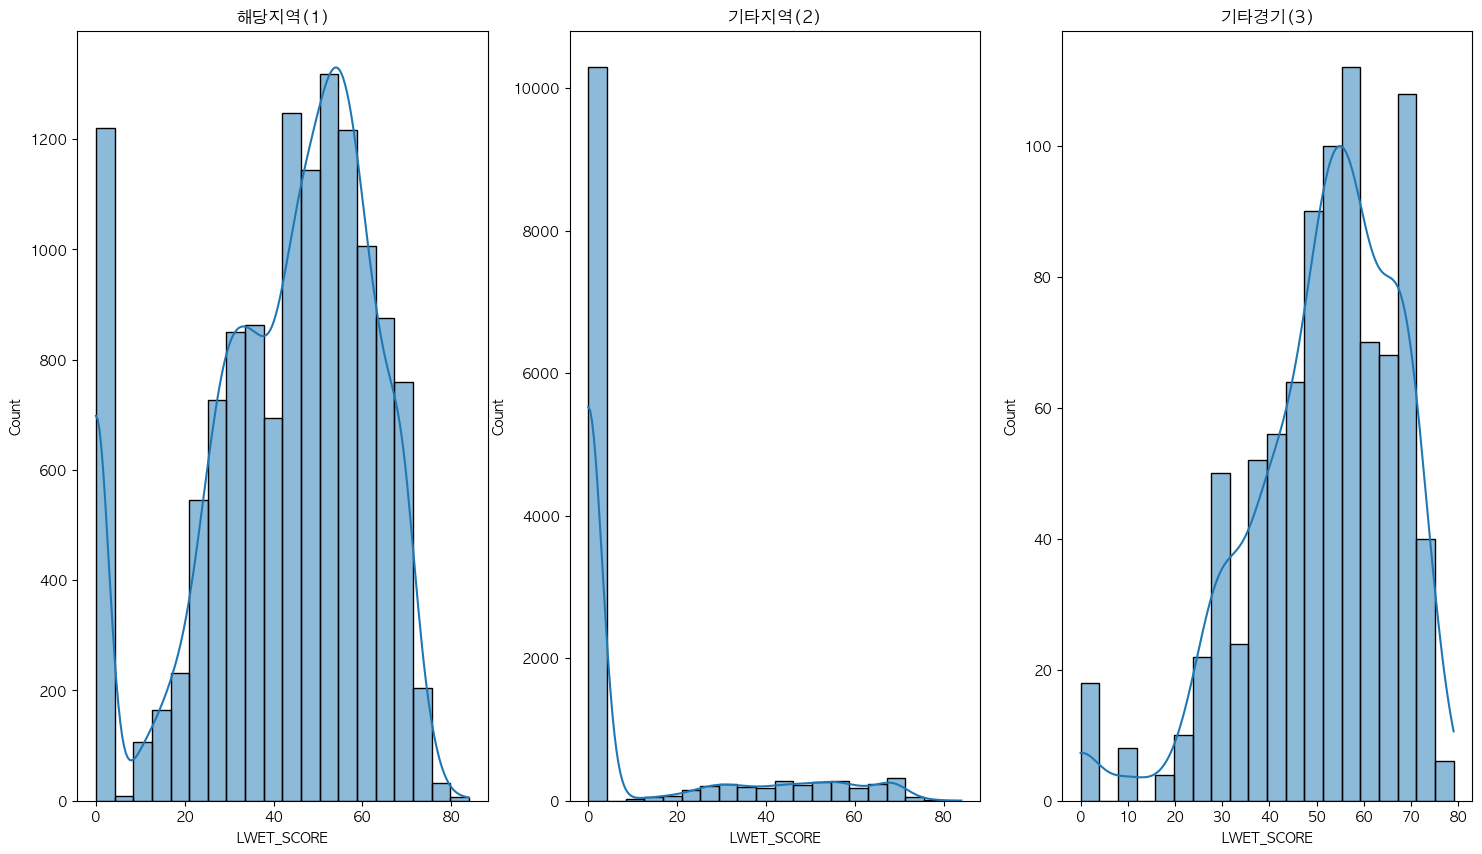

In [14]:
# 거주 지역 코드 별 통계값 확인 결과 기타 경기에서 데이터 개수가 적으며 최대값에 비해 평균이 낮음을 확인 따라서 분포 시각화를 통해 이상치 존재 여부 확인
plt.figure(figsize=(6*3, 10))

plt.subplot(1,3,1)
sns.histplot(data=score_df[score_df['RESIDE_SENM'] == '해당지역'], x='LWET_SCORE', bins=20, kde=True)
plt.title('해당지역(1)')
plt.subplot(1,3,2)
sns.histplot(data=score_df[score_df['RESIDE_SENM'] == '기타지역'], x='LWET_SCORE', bins=20, kde=True)
plt.title('기타지역(2)')
plt.subplot(1,3,3)
sns.histplot(data=score_df[score_df['RESIDE_SENM'] == '기타경기'], x='LWET_SCORE', bins=20, kde=True)
plt.title('기타경기(3)')

plt.show()

# 0점이 미달?
# 거주 지역 코드에 따라 데이터 분포가 달라짐 -> 신청 제한에 따른 영향 하나의 값으로 표현 가능?


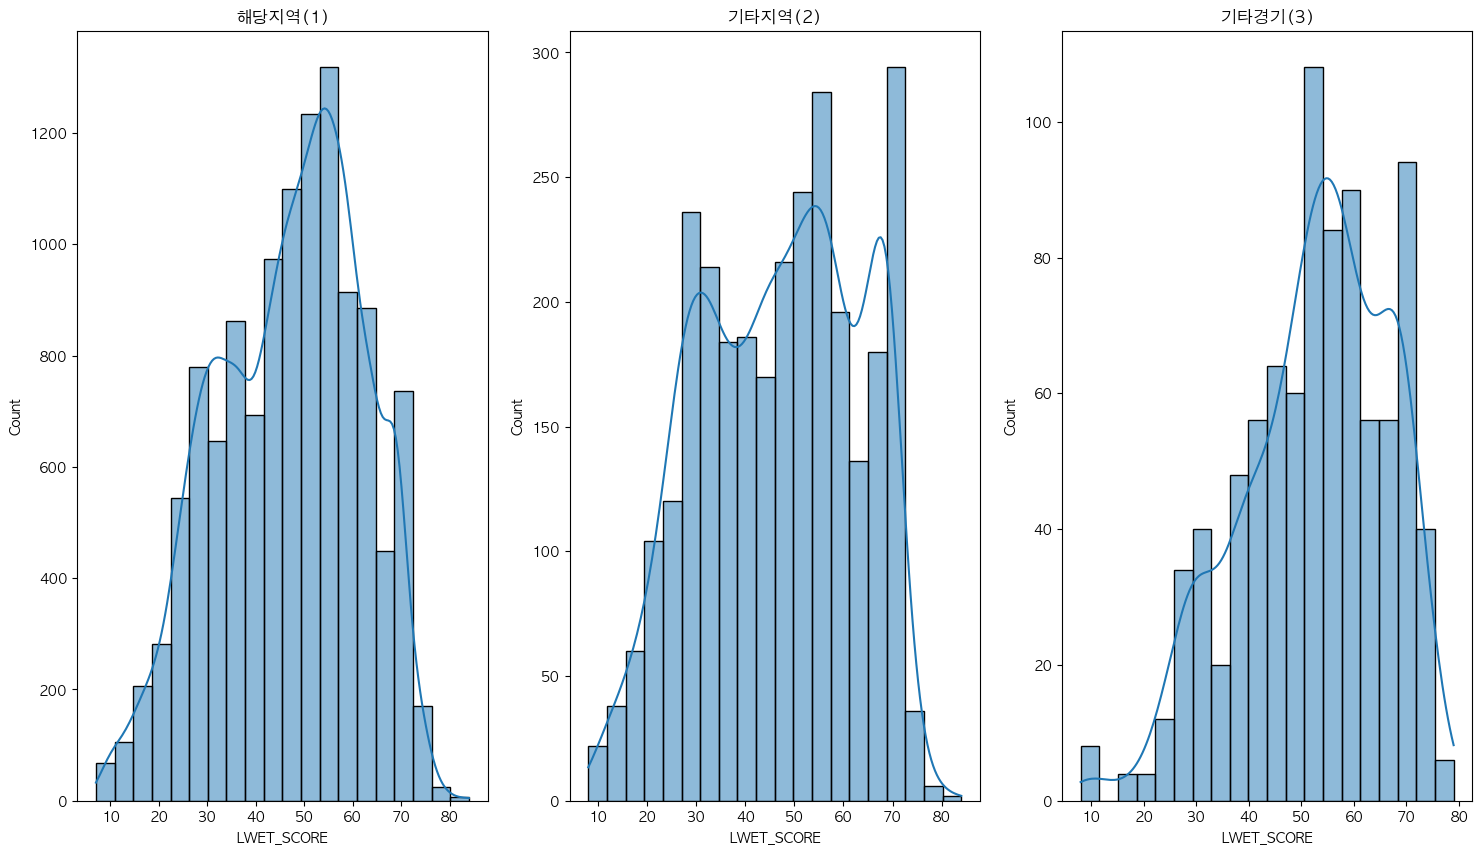

In [15]:
# 거주 지역 코드 별 통계값 확인 결과 기타 경기에서 데이터 개수가 적으며 최대값에 비해 평균이 낮음을 확인 따라서 분포 시각화를 통해 이상치 존재 여부 확인
plt.figure(figsize=(6*3, 10))

plt.subplot(1,3,1)
sns.histplot(data=score_df_cmpt_over_1[score_df_cmpt_over_1['RESIDE_SENM'] == '해당지역'], x='LWET_SCORE', bins=20, kde=True)
plt.title('해당지역(1)')
plt.subplot(1,3,2)
sns.histplot(data=score_df_cmpt_over_1[score_df_cmpt_over_1['RESIDE_SENM'] == '기타지역'], x='LWET_SCORE', bins=20, kde=True)
plt.title('기타지역(2)')
plt.subplot(1,3,3)
sns.histplot(data=score_df_cmpt_over_1[score_df_cmpt_over_1['RESIDE_SENM'] == '기타경기'], x='LWET_SCORE', bins=20, kde=True)
plt.title('기타경기(3)')

plt.show()

# 0점이 미달?

score_df_cmpt_over_1_RESD_3 = score_df_cmpt_over_1[score_df_cmpt_over_1['RESIDE_SENM'] == '기타경기']
score_df_cmpt_over_1_RESD_2 = score_df_cmpt_over_1[score_df_cmpt_over_1['RESIDE_SENM'] == '기타지역']
score_df_cmpt_over_1_RESD_1 = score_df_cmpt_over_1[score_df_cmpt_over_1['RESIDE_SENM'] == '해당지역']


---
## 투기과열지구 여부에 따른 최저 가점 차이 — 통계 검정

> **귀무가설 H₀**: 투기과열지구(Y)와 일반지역(N)의 최저 가점 분포는 동일하다.  
> **대립가설 H₁**: 두 그룹의 최저 가점 분포에 유의한 차이가 있다.  
>
> `LWET_SCORE`는 이산형 점수값 + 비정규 분포가 예상되므로 **Mann-Whitney U (비모수 검정)**을 주 검정으로 사용하고, 독립표본 t-검정은 참고용으로 병기합니다.

    그룹          n       평균      중앙값     표준편차
-------------------------------------------------------
 투기과열(Y)     6016    34.62    44.00    29.21
 일반지역(N)    21322    25.17    27.00    24.52

[정규성 검정]
  Shapiro-Wilk [투기과열(Y)]: W=0.8107, p=1.4920e-60  → 비정규 분포 ✗
  Shapiro-Wilk [일반지역(N)]: W=0.8320, p=2.4367e-58  → 비정규 분포 ✗

[등분산 검정] Levene: stat=657.0998, p=3.1489e-143  → 이분산 ✗

[Mann-Whitney U 검정]
  U=77841692.0,  p=3.8196e-153
  rank-biserial r = -0.2137  (|r|<0.1: 미미 / 0.1~0.3: 소 / 0.3~0.5: 중 / >0.5: 대)

[독립표본 t-검정 Welch] t=22.9198,  p=7.0664e-113
  Cohen's d = 0.3688  (|d|<0.2: 미미 / 0.2~0.5: 소 / 0.5~0.8: 중 / >0.8: 대)

✅ 유의수준 0.05에서 귀무가설 기각 → 두 그룹 간 최저 가점 분포에 통계적으로 유의한 차이 있음


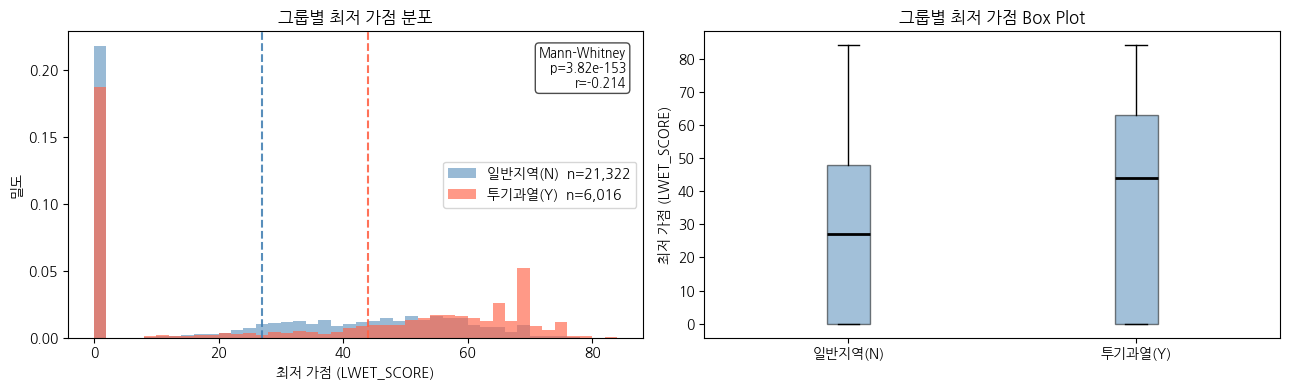

In [10]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── 0. 전처리: LWET_SCORE → 수치형, 미달/추첨제('-') 제거 ──────────────────
df_test = score_df.copy()
df_test['LWET_NUM'] = pd.to_numeric(df_test['LWET_SCORE'], errors='coerce')
df_test = df_test.dropna(subset=['LWET_NUM', 'SPECLT_RDN_EARTH_AT'])

group_Y = df_test.loc[df_test['SPECLT_RDN_EARTH_AT'] == 'Y', 'LWET_NUM'].values
group_N = df_test.loc[df_test['SPECLT_RDN_EARTH_AT'] == 'N', 'LWET_NUM'].values

print("=" * 55)
print(f"{'그룹':^10} {'n':>6} {'평균':>8} {'중앙값':>8} {'표준편차':>8}")
print("-" * 55)
for lbl, g in [('투기과열(Y)', group_Y), ('일반지역(N)', group_N)]:
    print(f"{lbl:^10} {len(g):>6} {g.mean():>8.2f} {np.median(g):>8.2f} {g.std():>8.2f}")
print("=" * 55)

# ── 1. 정규성 검정 (Shapiro-Wilk, n≤5000 샘플링) ──────────────────────────
def shapiro_safe(arr, label, n=5000):
    sample = arr if len(arr) <= n else np.random.choice(arr, n, replace=False)
    stat, p = stats.shapiro(sample)
    print(f"  Shapiro-Wilk [{label}]: W={stat:.4f}, p={p:.4e}  "
          f"→ {'비정규 분포 ✗' if p < 0.05 else '정규 분포 ✓'}")

print("\n[정규성 검정]")
shapiro_safe(group_Y, '투기과열(Y)')
shapiro_safe(group_N, '일반지역(N)')

# ── 2. 등분산 검정 (Levene) ────────────────────────────────────────────────
lev_stat, lev_p = stats.levene(group_Y, group_N)
print(f"\n[등분산 검정] Levene: stat={lev_stat:.4f}, p={lev_p:.4e}  "
      f"→ {'이분산 ✗' if lev_p < 0.05 else '등분산 ✓'}")

# ── 3. Mann-Whitney U 검정 (비모수, 주 검정) ──────────────────────────────
mw_stat, mw_p = stats.mannwhitneyu(group_Y, group_N, alternative='two-sided')

# 효과 크기: rank-biserial correlation  r = 1 - 2U/(n1*n2)
r_rb = 1 - (2 * mw_stat) / (len(group_Y) * len(group_N))
print(f"\n[Mann-Whitney U 검정]")
print(f"  U={mw_stat:.1f},  p={mw_p:.4e}")
print(f"  rank-biserial r = {r_rb:.4f}  "
      f"(|r|<0.1: 미미 / 0.1~0.3: 소 / 0.3~0.5: 중 / >0.5: 대)")

# ── 4. 독립표본 t-검정 (참고용) ────────────────────────────────────────────
equal_var = lev_p >= 0.05
t_stat, t_p = stats.ttest_ind(group_Y, group_N, equal_var=equal_var)
print(f"\n[독립표본 t-검정 {'등분산' if equal_var else 'Welch'}] "
      f"t={t_stat:.4f},  p={t_p:.4e}")

# ── 5. Cohen's d ───────────────────────────────────────────────────────────
pooled_std = np.sqrt(
    ((len(group_Y)-1)*group_Y.std()**2 + (len(group_N)-1)*group_N.std()**2)
    / (len(group_Y) + len(group_N) - 2)
)
cohens_d = (group_Y.mean() - group_N.mean()) / pooled_std
print(f"  Cohen's d = {cohens_d:.4f}  "
      f"(|d|<0.2: 미미 / 0.2~0.5: 소 / 0.5~0.8: 중 / >0.8: 대)")

# ── 6. 결론 ────────────────────────────────────────────────────────────────
alpha = 0.05
print("\n" + "=" * 55)
if mw_p < alpha:
    print(f"✅ 유의수준 {alpha}에서 귀무가설 기각 → 두 그룹 간 최저 가점 분포에 통계적으로 유의한 차이 있음")
else:
    print(f"❌ 유의수준 {alpha}에서 귀무가설 채택 → 두 그룹 간 유의한 차이 없음")
print("=" * 55)

# ── 7. 시각화 ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 분포 히스토그램
ax = axes[0]
bins = np.arange(0, 85, 2)
ax.hist(group_N, bins=bins, alpha=0.55, label=f'일반지역(N)  n={len(group_N):,}', color='steelblue', density=True)
ax.hist(group_Y, bins=bins, alpha=0.65, label=f'투기과열(Y)  n={len(group_Y):,}', color='tomato',    density=True)
ax.axvline(np.median(group_N), color='steelblue', lw=1.5, ls='--', alpha=0.9)
ax.axvline(np.median(group_Y), color='tomato',    lw=1.5, ls='--', alpha=0.9)
ax.set_xlabel('최저 가점 (LWET_SCORE)')
ax.set_ylabel('밀도')
ax.set_title('그룹별 최저 가점 분포')
ax.legend()
ax.text(0.97, 0.95,
        f'Mann-Whitney\np={mw_p:.2e}\nr={r_rb:.3f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# Box plot
ax2 = axes[1]
ax2.boxplot([group_N, group_Y], labels=['일반지역(N)', '투기과열(Y)'],
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.5),
            medianprops=dict(color='black', lw=2))
ax2.set_ylabel('최저 가점 (LWET_SCORE)')
ax2.set_title('그룹별 최저 가점 Box Plot')
ax2.yaxis.set_major_locator(ticker.MultipleLocator(10))

plt.tight_layout()
plt.show()

    그룹          n       평균      중앙값     표준편차
-------------------------------------------------------
 투기과열(Y)     2828    53.86    56.00    14.84
 일반지역(N)     9170    44.66    46.00    14.07

[정규성 검정]
  Shapiro-Wilk [투기과열(Y)]: W=0.9395, p=1.6838e-32  → 비정규 분포 ✗
  Shapiro-Wilk [일반지역(N)]: W=0.9831, p=5.1697e-24  → 비정규 분포 ✗

[등분산 검정] Levene: stat=0.2844, p=5.9383e-01  → 등분산 ✓

[Mann-Whitney U 검정]
  U=17789374.0,  p=3.3803e-197
  rank-biserial r = -0.3720  (|r|<0.1: 미미 / 0.1~0.3: 소 / 0.3~0.5: 중 / >0.5: 대)

[독립표본 t-검정 등분산] t=29.9862,  p=1.4407e-190
  Cohen's d = 0.6450  (|d|<0.2: 미미 / 0.2~0.5: 소 / 0.5~0.8: 중 / >0.8: 대)

✅ 유의수준 0.05에서 귀무가설 기각 → 두 그룹 간 최저 가점 분포에 통계적으로 유의한 차이 있음


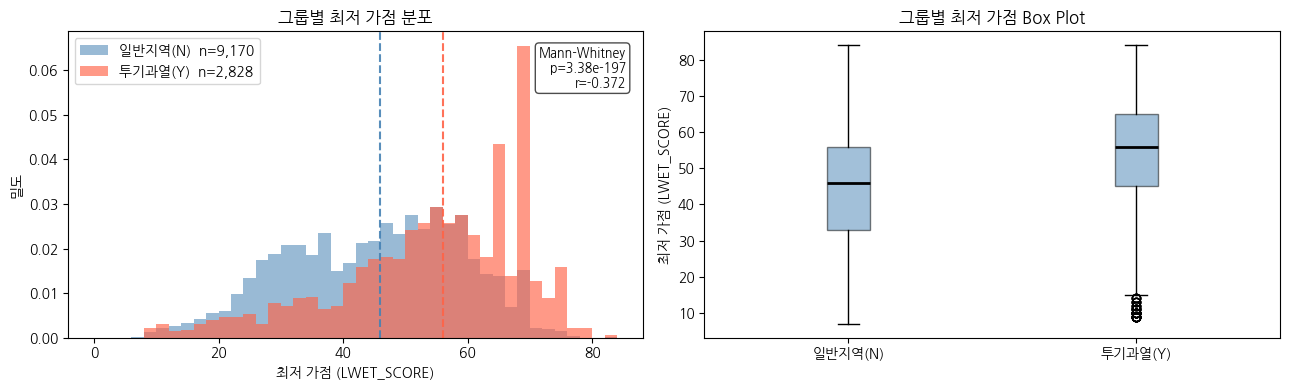

    그룹          n       평균      중앙값     표준편차
-------------------------------------------------------
 투기과열(Y)      808    58.51    63.00    14.41
 일반지역(N)     2120    42.27    42.00    14.17

[정규성 검정]
  Shapiro-Wilk [투기과열(Y)]: W=0.8270, p=1.1921e-28  → 비정규 분포 ✗
  Shapiro-Wilk [일반지역(N)]: W=0.9852, p=4.7867e-14  → 비정규 분포 ✗

[등분산 검정] Levene: stat=23.5444, p=1.2846e-06  → 이분산 ✗

[Mann-Whitney U 검정]
  U=1380610.0,  p=4.9497e-145
  rank-biserial r = -0.6120  (|r|<0.1: 미미 / 0.1~0.3: 소 / 0.3~0.5: 중 / >0.5: 대)

[독립표본 t-검정 Welch] t=27.3772,  p=3.7729e-133
  Cohen's d = 1.1409  (|d|<0.2: 미미 / 0.2~0.5: 소 / 0.5~0.8: 중 / >0.8: 대)

✅ 유의수준 0.05에서 귀무가설 기각 → 두 그룹 간 최저 가점 분포에 통계적으로 유의한 차이 있음


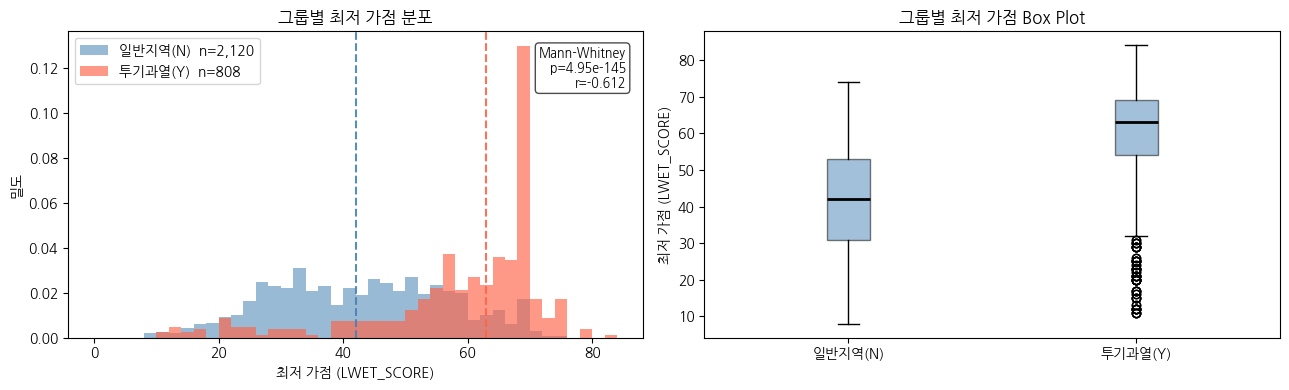

    그룹          n       평균      중앙값     표준편차
-------------------------------------------------------
 투기과열(Y)      134    65.06    69.00    11.41
 일반지역(N)      750    50.14    52.00    13.13

[정규성 검정]
  Shapiro-Wilk [투기과열(Y)]: W=0.6909, p=1.9745e-15  → 비정규 분포 ✗
  Shapiro-Wilk [일반지역(N)]: W=0.9740, p=2.7315e-10  → 비정규 분포 ✗

[등분산 검정] Levene: stat=26.2143, p=3.7523e-07  → 이분산 ✗

[Mann-Whitney U 검정]
  U=84916.0,  p=3.4628e-37
  rank-biserial r = -0.6899  (|r|<0.1: 미미 / 0.1~0.3: 소 / 0.3~0.5: 중 / >0.5: 대)

[독립표본 t-검정 Welch] t=13.5768,  p=3.1862e-30
  Cohen's d = 1.1583  (|d|<0.2: 미미 / 0.2~0.5: 소 / 0.5~0.8: 중 / >0.8: 대)

✅ 유의수준 0.05에서 귀무가설 기각 → 두 그룹 간 최저 가점 분포에 통계적으로 유의한 차이 있음


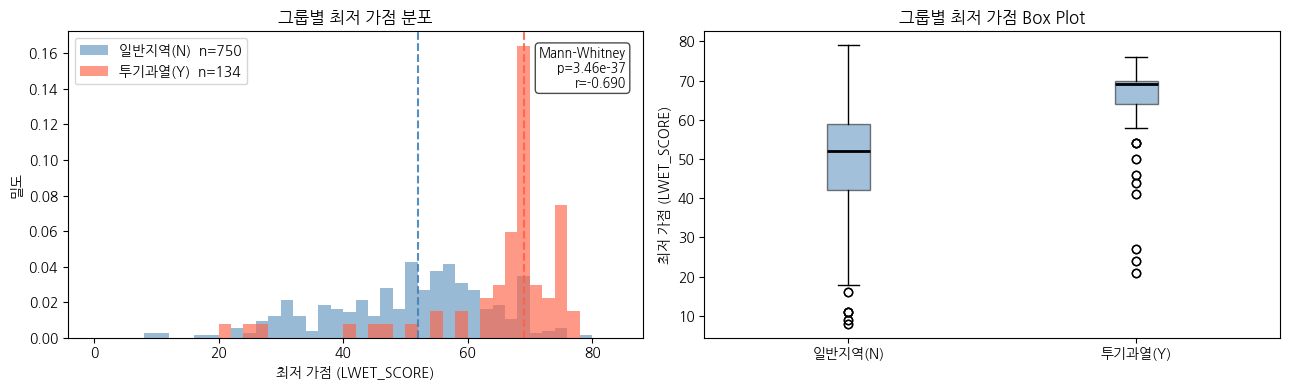

In [11]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def test_two_group_mean(df, target='LWET_NUM'):
    # ── 0. 전처리: LWET_SCORE → 수치형, 미달/추첨제('-') 제거 ──────────────────
    df_test = df.copy()
    df_test[target] = pd.to_numeric(df_test['LWET_SCORE'], errors='coerce')
    df_test = df_test.dropna(subset=[target, 'SPECLT_RDN_EARTH_AT'])

    group_Y = df_test.loc[df_test['SPECLT_RDN_EARTH_AT'] == 'Y', target].values
    group_N = df_test.loc[df_test['SPECLT_RDN_EARTH_AT'] == 'N', target].values

    print("=" * 55)
    print(f"{'그룹':^10} {'n':>6} {'평균':>8} {'중앙값':>8} {'표준편차':>8}")
    print("-" * 55)
    for lbl, g in [('투기과열(Y)', group_Y), ('일반지역(N)', group_N)]:
        print(f"{lbl:^10} {len(g):>6} {g.mean():>8.2f} {np.median(g):>8.2f} {g.std():>8.2f}")
    print("=" * 55)

    # ── 1. 정규성 검정 (Shapiro-Wilk, n≤5000 샘플링) ──────────────────────────
    def shapiro_safe(arr, label, n=5000):
        sample = arr if len(arr) <= n else np.random.choice(arr, n, replace=False)
        stat, p = stats.shapiro(sample)
        print(f"  Shapiro-Wilk [{label}]: W={stat:.4f}, p={p:.4e}  "
            f"→ {'비정규 분포 ✗' if p < 0.05 else '정규 분포 ✓'}")

    print("\n[정규성 검정]")
    shapiro_safe(group_Y, '투기과열(Y)')
    shapiro_safe(group_N, '일반지역(N)')

    # ── 2. 등분산 검정 (Levene) ────────────────────────────────────────────────
    lev_stat, lev_p = stats.levene(group_Y, group_N)
    print(f"\n[등분산 검정] Levene: stat={lev_stat:.4f}, p={lev_p:.4e}  "
        f"→ {'이분산 ✗' if lev_p < 0.05 else '등분산 ✓'}")

    # ── 3. Mann-Whitney U 검정 (비모수, 주 검정) ──────────────────────────────
    mw_stat, mw_p = stats.mannwhitneyu(group_Y, group_N, alternative='two-sided')

    # 효과 크기: rank-biserial correlation  r = 1 - 2U/(n1*n2)
    r_rb = 1 - (2 * mw_stat) / (len(group_Y) * len(group_N))
    print(f"\n[Mann-Whitney U 검정]")
    print(f"  U={mw_stat:.1f},  p={mw_p:.4e}")
    print(f"  rank-biserial r = {r_rb:.4f}  "
        f"(|r|<0.1: 미미 / 0.1~0.3: 소 / 0.3~0.5: 중 / >0.5: 대)")

    # ── 4. 독립표본 t-검정 (참고용) ────────────────────────────────────────────
    equal_var = lev_p >= 0.05
    t_stat, t_p = stats.ttest_ind(group_Y, group_N, equal_var=equal_var)
    print(f"\n[독립표본 t-검정 {'등분산' if equal_var else 'Welch'}] "
        f"t={t_stat:.4f},  p={t_p:.4e}")

    # ── 5. Cohen's d ───────────────────────────────────────────────────────────
    pooled_std = np.sqrt(
        ((len(group_Y)-1)*group_Y.std()**2 + (len(group_N)-1)*group_N.std()**2)
        / (len(group_Y) + len(group_N) - 2)
    )
    cohens_d = (group_Y.mean() - group_N.mean()) / pooled_std
    print(f"  Cohen's d = {cohens_d:.4f}  "
        f"(|d|<0.2: 미미 / 0.2~0.5: 소 / 0.5~0.8: 중 / >0.8: 대)")

    # ── 6. 결론 ────────────────────────────────────────────────────────────────
    alpha = 0.05
    print("\n" + "=" * 55)
    if mw_p < alpha:
        print(f"✅ 유의수준 {alpha}에서 귀무가설 기각 → 두 그룹 간 최저 가점 분포에 통계적으로 유의한 차이 있음")
    else:
        print(f"❌ 유의수준 {alpha}에서 귀무가설 채택 → 두 그룹 간 유의한 차이 없음")
    print("=" * 55)

    # ── 7. 시각화 ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # 분포 히스토그램
    ax = axes[0]
    bins = np.arange(0, 85, 2)
    ax.hist(group_N, bins=bins, alpha=0.55, label=f'일반지역(N)  n={len(group_N):,}', color='steelblue', density=True)
    ax.hist(group_Y, bins=bins, alpha=0.65, label=f'투기과열(Y)  n={len(group_Y):,}', color='tomato',    density=True)
    ax.axvline(np.median(group_N), color='steelblue', lw=1.5, ls='--', alpha=0.9)
    ax.axvline(np.median(group_Y), color='tomato',    lw=1.5, ls='--', alpha=0.9)
    ax.set_xlabel('최저 가점 (LWET_SCORE)')
    ax.set_ylabel('밀도')
    ax.set_title('그룹별 최저 가점 분포')
    ax.legend()
    ax.text(0.97, 0.95,
            f'Mann-Whitney\np={mw_p:.2e}\nr={r_rb:.3f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    # Box plot
    ax2 = axes[1]
    ax2.boxplot([group_N, group_Y], labels=['일반지역(N)', '투기과열(Y)'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='black', lw=2))
    ax2.set_ylabel('최저 가점 (LWET_SCORE)')
    ax2.set_title('그룹별 최저 가점 Box Plot')
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(10))

    plt.tight_layout()
    plt.show()

test_two_group_mean(score_df_cmpt_over_1_RESD_1)
test_two_group_mean(score_df_cmpt_over_1_RESD_2)
test_two_group_mean(score_df_cmpt_over_1_RESD_3)

    그룹          n       평균      중앙값     표준편차
-------------------------------------------------------
 투기과열(Y)     3770    55.25    58.00    14.88
 일반지역(N)    12040    44.58    46.00    14.13

[정규성 검정]
  Shapiro-Wilk [투기과열(Y)]: W=0.9174, p=2.5744e-41  → 비정규 분포 ✗
  Shapiro-Wilk [일반지역(N)]: W=0.9846, p=6.2576e-23  → 비정규 분포 ✗

[등분산 검정] Levene: stat=2.7245, p=9.8837e-02  → 등분산 ✓

[Mann-Whitney U 검정]
  U=32424866.0,  p=0.0000e+00
  rank-biserial r = -0.4287  (|r|<0.1: 미미 / 0.1~0.3: 소 / 0.3~0.5: 중 / >0.5: 대)

[독립표본 t-검정 등분산] t=39.9411,  p=0.0000e+00
  Cohen's d = 0.7455  (|d|<0.2: 미미 / 0.2~0.5: 소 / 0.5~0.8: 중 / >0.8: 대)

✅ 유의수준 0.05에서 귀무가설 기각 → 두 그룹 간 최저 가점 분포에 통계적으로 유의한 차이 있음


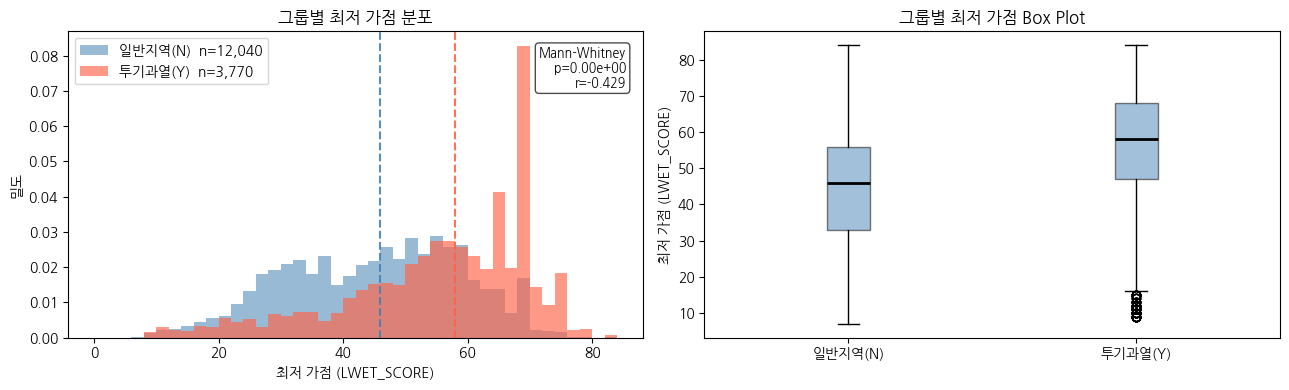

In [12]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── 0. 전처리: LWET_SCORE → 수치형, 미달/추첨제('-') 제거 ──────────────────
df_test = score_df_cmpt_over_1.copy()
df_test['LWET_NUM'] = pd.to_numeric(df_test['LWET_SCORE'], errors='coerce')
df_test = df_test.dropna(subset=['LWET_NUM', 'SPECLT_RDN_EARTH_AT'])

group_Y = df_test.loc[df_test['SPECLT_RDN_EARTH_AT'] == 'Y', 'LWET_NUM'].values
group_N = df_test.loc[df_test['SPECLT_RDN_EARTH_AT'] == 'N', 'LWET_NUM'].values

print("=" * 55)
print(f"{'그룹':^10} {'n':>6} {'평균':>8} {'중앙값':>8} {'표준편차':>8}")
print("-" * 55)
for lbl, g in [('투기과열(Y)', group_Y), ('일반지역(N)', group_N)]:
    print(f"{lbl:^10} {len(g):>6} {g.mean():>8.2f} {np.median(g):>8.2f} {g.std():>8.2f}")
print("=" * 55)

# ── 1. 정규성 검정 (Shapiro-Wilk, n≤5000 샘플링) ──────────────────────────
def shapiro_safe(arr, label, n=5000):
    sample = arr if len(arr) <= n else np.random.choice(arr, n, replace=False)
    stat, p = stats.shapiro(sample)
    print(f"  Shapiro-Wilk [{label}]: W={stat:.4f}, p={p:.4e}  "
          f"→ {'비정규 분포 ✗' if p < 0.05 else '정규 분포 ✓'}")

print("\n[정규성 검정]")
shapiro_safe(group_Y, '투기과열(Y)')
shapiro_safe(group_N, '일반지역(N)')

# ── 2. 등분산 검정 (Levene) ────────────────────────────────────────────────
lev_stat, lev_p = stats.levene(group_Y, group_N)
print(f"\n[등분산 검정] Levene: stat={lev_stat:.4f}, p={lev_p:.4e}  "
      f"→ {'이분산 ✗' if lev_p < 0.05 else '등분산 ✓'}")

# ── 3. Mann-Whitney U 검정 (비모수, 주 검정) ──────────────────────────────
mw_stat, mw_p = stats.mannwhitneyu(group_Y, group_N, alternative='two-sided')

# 효과 크기: rank-biserial correlation  r = 1 - 2U/(n1*n2)
r_rb = 1 - (2 * mw_stat) / (len(group_Y) * len(group_N))
print(f"\n[Mann-Whitney U 검정]")
print(f"  U={mw_stat:.1f},  p={mw_p:.4e}")
print(f"  rank-biserial r = {r_rb:.4f}  "
      f"(|r|<0.1: 미미 / 0.1~0.3: 소 / 0.3~0.5: 중 / >0.5: 대)")

# ── 4. 독립표본 t-검정 (참고용) ────────────────────────────────────────────
equal_var = lev_p >= 0.05
t_stat, t_p = stats.ttest_ind(group_Y, group_N, equal_var=equal_var)
print(f"\n[독립표본 t-검정 {'등분산' if equal_var else 'Welch'}] "
      f"t={t_stat:.4f},  p={t_p:.4e}")

# ── 5. Cohen's d ───────────────────────────────────────────────────────────
pooled_std = np.sqrt(
    ((len(group_Y)-1)*group_Y.std()**2 + (len(group_N)-1)*group_N.std()**2)
    / (len(group_Y) + len(group_N) - 2)
)
cohens_d = (group_Y.mean() - group_N.mean()) / pooled_std
print(f"  Cohen's d = {cohens_d:.4f}  "
      f"(|d|<0.2: 미미 / 0.2~0.5: 소 / 0.5~0.8: 중 / >0.8: 대)")

# ── 6. 결론 ────────────────────────────────────────────────────────────────
alpha = 0.05
print("\n" + "=" * 55)
if mw_p < alpha:
    print(f"✅ 유의수준 {alpha}에서 귀무가설 기각 → 두 그룹 간 최저 가점 분포에 통계적으로 유의한 차이 있음")
else:
    print(f"❌ 유의수준 {alpha}에서 귀무가설 채택 → 두 그룹 간 유의한 차이 없음")
print("=" * 55)

# ── 7. 시각화 ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 분포 히스토그램
ax = axes[0]
bins = np.arange(0, 85, 2)
ax.hist(group_N, bins=bins, alpha=0.55, label=f'일반지역(N)  n={len(group_N):,}', color='steelblue', density=True)
ax.hist(group_Y, bins=bins, alpha=0.65, label=f'투기과열(Y)  n={len(group_Y):,}', color='tomato',    density=True)
ax.axvline(np.median(group_N), color='steelblue', lw=1.5, ls='--', alpha=0.9)
ax.axvline(np.median(group_Y), color='tomato',    lw=1.5, ls='--', alpha=0.9)
ax.set_xlabel('최저 가점 (LWET_SCORE)')
ax.set_ylabel('밀도')
ax.set_title('그룹별 최저 가점 분포')
ax.legend()
ax.text(0.97, 0.95,
        f'Mann-Whitney\np={mw_p:.2e}\nr={r_rb:.3f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# Box plot
ax2 = axes[1]
ax2.boxplot([group_N, group_Y], labels=['일반지역(N)', '투기과열(Y)'],
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.5),
            medianprops=dict(color='black', lw=2))
ax2.set_ylabel('최저 가점 (LWET_SCORE)')
ax2.set_title('그룹별 최저 가점 Box Plot')
ax2.yaxis.set_major_locator(ticker.MultipleLocator(10))

plt.tight_layout()
plt.show()

In [13]:
# 상위 브랜드 필터링
# 정규표현식(OR 조건)을 활용한 필터링
brands = ['래미안', '힐스테이트', '푸르지오', '아이파크', '자이', 'e편한세상', '더샵', '롯데캐슬']
pattern = '|'.join(brands)
# 필터링 및 빈도수 계산
top_brand_score = score_df[score_df['HOUSE_NM'].str.contains(pattern, na=False, regex=True)]

not_top_brand_score = score_df[~score_df['HOUSE_NM'].str.contains(pattern, na=False, regex=True)]

# 상위 브랜드에 따라 점수 분포 달라짐

상위 브랜드 가점 커트라인 통계값
 mean      27.990117
std       27.415981
median    29.000000
min        0.000000
max       84.000000
Name: LWET_SCORE, dtype: float64
비상위 브랜드 가점 커트라인 통계값
 mean      26.764168
std       24.870796
median    29.000000
min        0.000000
max       84.000000
Name: LWET_SCORE, dtype: float64


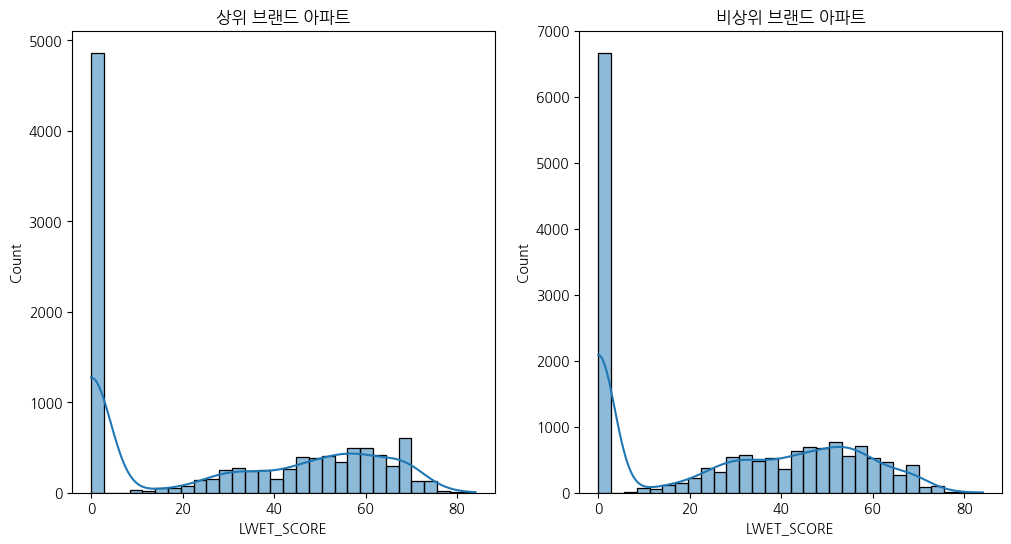

In [14]:
print('상위 브랜드 가점 커트라인 통계값\n', top_brand_score['LWET_SCORE'].agg(['mean', 'std', 'median', 'min', 'max']))

print('비상위 브랜드 가점 커트라인 통계값\n', not_top_brand_score['LWET_SCORE'].agg(['mean', 'std', 'median', 'min', 'max']))


plt.figure(figsize=(6*2, 6))

plt.subplot(1,2,1)
sns.histplot(top_brand_score['LWET_SCORE'], bins=30, kde=True)
plt.title('상위 브랜드 아파트')

plt.subplot(1,2,2)
sns.histplot(not_top_brand_score['LWET_SCORE'], bins=30, kde=True)
plt.title('비상위 브랜드 아파트')

plt.show()

# brand_value = 탑 브랜드 1 그렇지 않은 브랜드 0?

상위 브랜드 가점 커트라인 통계값
 mean      50.408042
std       14.950177
median    53.000000
min        8.000000
max       84.000000
Name: LWET_SCORE, dtype: float64
비상위 브랜드 가점 커트라인 통계값
 mean      45.083145
std       14.697437
median    46.000000
min        7.000000
max       84.000000
Name: LWET_SCORE, dtype: float64


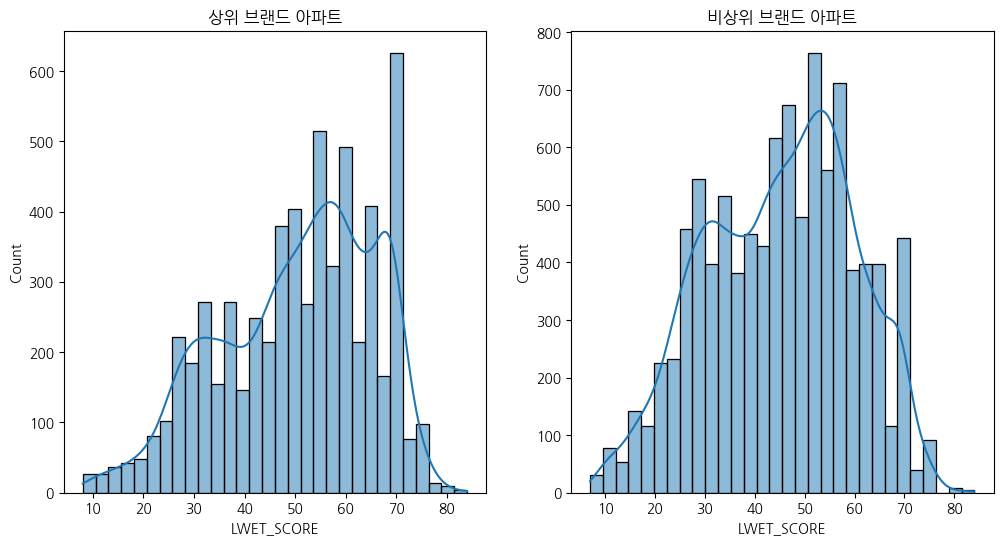

In [15]:
# 상위 브랜드 필터링
# 정규표현식(OR 조건)을 활용한 필터링
brands = ['래미안', '힐스테이트', '푸르지오', '아이파크', '자이', 'e편한세상', '더샵', '롯데캐슬']
pattern = '|'.join(brands)
# 필터링 및 빈도수 계산
top_brand_score_over_1 = score_df_cmpt_over_1[score_df_cmpt_over_1['HOUSE_NM'].str.contains(pattern, na=False, regex=True)]

not_top_brand_score_over_1 = score_df_cmpt_over_1[~score_df_cmpt_over_1['HOUSE_NM'].str.contains(pattern, na=False, regex=True)]

print('상위 브랜드 가점 커트라인 통계값\n', top_brand_score_over_1['LWET_SCORE'].agg(['mean', 'std', 'median', 'min', 'max']))

print('비상위 브랜드 가점 커트라인 통계값\n', not_top_brand_score_over_1['LWET_SCORE'].agg(['mean', 'std', 'median', 'min', 'max']))


plt.figure(figsize=(6*2, 6))

plt.subplot(1,2,1)
sns.histplot(top_brand_score_over_1['LWET_SCORE'], bins=30, kde=True)
plt.title('상위 브랜드 아파트')

plt.subplot(1,2,2)
sns.histplot(not_top_brand_score_over_1['LWET_SCORE'], bins=30, kde=True)
plt.title('비상위 브랜드 아파트')

plt.show()


In [16]:
from scipy import stats


GROUP_A = top_brand_score_over_1['LWET_SCORE'].dropna().values
GROUP_B = not_top_brand_score_over_1['LWET_SCORE'].dropna().values

def shapiro_safe(arr, label, n=5000):
    if len(arr) > n:
        arr = np.random.choice(arr, n, replace=False)
    stat, p = stats.shapiro(arr)
    print(f"Shapiro-Wilk test for {label}: Statistics={stat:.3f}, p-value={p:.3e}")
    return p

shapiro_safe(GROUP_A, '상위 브랜드')
shapiro_safe(GROUP_B, '비상위 브랜드')


lv_stat, lv_p = stats.levene(GROUP_A, GROUP_B)
print('등분산 검증 : ', lv_p)

# ── 3. Mann-Whitney U 검정 (비모수, 주 검정) ──────────────────────────────
mw_stat, mw_p = stats.mannwhitneyu(GROUP_A, GROUP_B, alternative='two-sided')

# 효과 크기: rank-biserial correlation  r = 1 - 2U/(n1*n2)
r_rb = 1 - (2 * mw_stat) / (len(GROUP_A) * len(GROUP_B))
print(f"\n[Mann-Whitney U 검정]")
print(f"  U={mw_stat:.1f},  p={mw_p:.4e}")
print(f"  rank-biserial r = {r_rb:.4f}  "
      f"(|r|<0.1: 미미 / 0.1~0.3: 소 / 0.3~0.5: 중 / >0.5: 대)")

# ── 4. 독립표본 t-검정 (참고용) ────────────────────────────────────────────
equal_var = lv_p >= 0.05
t_stat, t_p = stats.ttest_ind(GROUP_A, GROUP_B, equal_var=equal_var)
print(f"\n[독립표본 t-검정 {'등분산' if equal_var else 'Welch'}] "
      f"t={t_stat:.4f},  p={t_p:.4e}")

# ── 5. Cohen's d ───────────────────────────────────────────────────────────
pooled_std = np.sqrt(
    ((len(GROUP_A)-1)*GROUP_A.std()**2 + (len(GROUP_B)-1)*GROUP_B.std()**2)
    / (len(GROUP_A) + len(GROUP_B) - 2)
)
cohens_d = (GROUP_A.mean() - GROUP_B.mean()) / pooled_std
print(f"  Cohen's d = {cohens_d:.4f}  "
      f"(|d|<0.2: 미미 / 0.2~0.5: 소 / 0.5~0.8: 중 / >0.8: 대)")

# ── 6. 결론 ────────────────────────────────────────────────────────────────
alpha = 0.05
print("\n" + "=" * 55)
if mw_p < alpha:
    print(f"✅ 유의수준 {alpha}에서 귀무가설 기각 → 두 그룹 간 통계적으로 유의한 차이 있음")
else:
    print(f"❌ 유의수준 {alpha}에서 귀무가설 채택 → 두 그룹 간 유의한 차이 없음")
print("=" * 55)


Shapiro-Wilk test for 상위 브랜드: Statistics=0.965, p-value=2.926e-33
Shapiro-Wilk test for 비상위 브랜드: Statistics=0.983, p-value=4.261e-24
등분산 검증 :  0.6664619360735609

[Mann-Whitney U 검정]
  U=35777026.0,  p=4.3431e-110
  rank-biserial r = -0.2104  (|r|<0.1: 미미 / 0.1~0.3: 소 / 0.3~0.5: 중 / >0.5: 대)

[독립표본 t-검정 등분산] t=22.0079,  p=9.3170e-106
  Cohen's d = 0.3599  (|d|<0.2: 미미 / 0.2~0.5: 소 / 0.5~0.8: 중 / >0.8: 대)

✅ 유의수준 0.05에서 귀무가설 기각 → 두 그룹 간 통계적으로 유의한 차이 있음


In [17]:
# HOUSE_TY에 따른 청약 점수 

HOUSE_TY_V0 = score_df['HOUSE_TY'].str.extract(r'(\d+)').astype(int)
score_df['HOUSE_TY_V0'] = HOUSE_TY_V0
HOUSE_TY_V0.values.flatten()

array([74, 74, 74, ..., 84, 84, 84])

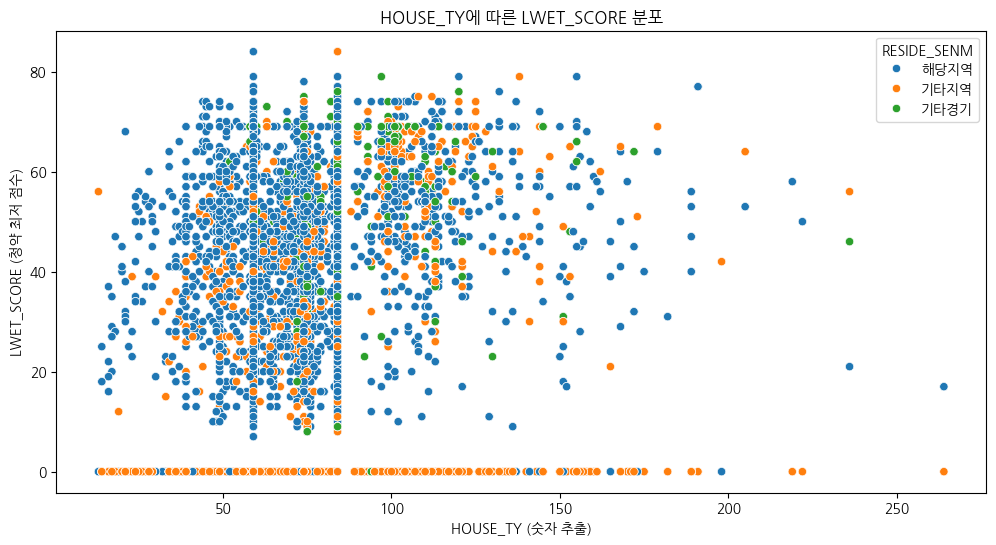

LWET_SCORE                 
                  mean        std count
HOUSE_TY_V0                            
13              28.000  32.331615     4
14              10.750  11.792855     8
16              11.750  13.493208    16
17              13.875  14.854292    16
18              18.750  21.292185     8
...                ...        ...   ...
205             58.500   6.350853     4
219             29.000  33.486316     4
222             25.000  28.867513     4
236             41.000  16.124515     6
264              8.500   9.814955     4

[157 rows x 3 columns]

In [18]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=HOUSE_TY_V0.values.flatten(), y=score_df['LWET_SCORE'].values, color='orange', hue=score_df['RESIDE_SENM'])
plt.xlabel('HOUSE_TY (숫자 추출)')
plt.ylabel('LWET_SCORE (청약 최저 점수)')
plt.title('HOUSE_TY에 따른 LWET_SCORE 분포')
plt.show()

display(score_df.groupby('HOUSE_TY_V0').agg({'LWET_SCORE': ['mean', 'std', 'count']}))

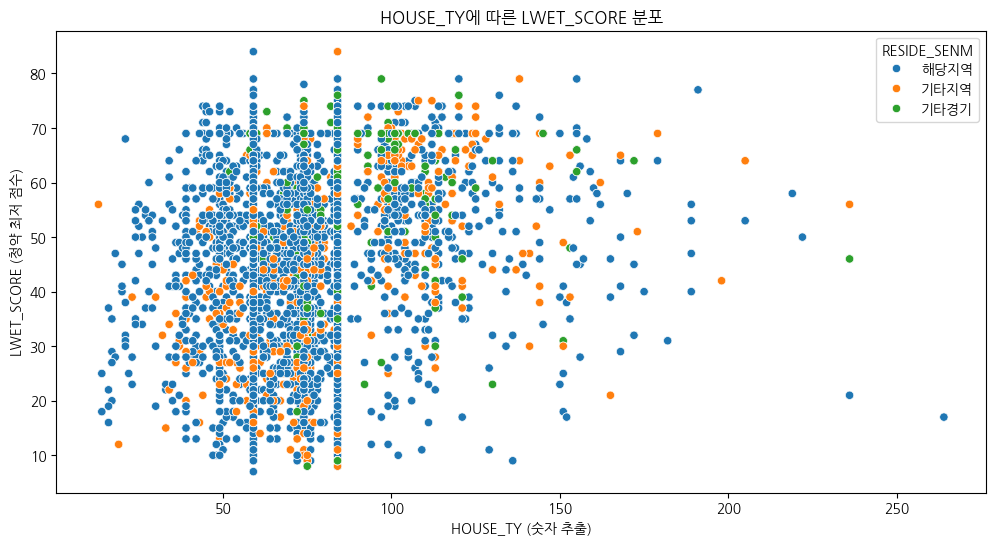

LWET_SCORE                 
                  mean        std count
HOUSE_TY_V1                            
13               56.00   0.000000     2
14               21.50   4.041452     4
16               23.50   8.635475     8
17               27.75   5.725881     8
18               37.50  10.969655     4
...                ...        ...   ...
205              58.50   6.350853     4
219              58.00   0.000000     2
222              50.00   0.000000     2
236              41.00  16.124515     6
264              17.00   0.000000     2

[156 rows x 3 columns]

In [19]:
# HOUSE_TY에 따른 청약 점수 

HOUSE_TY_V1 = score_df_cmpt_over_1['HOUSE_TY'].str.extract(r'(\d+)').astype(int)
score_df_cmpt_over_1['HOUSE_TY_V1'] = HOUSE_TY_V1
plt.figure(figsize=(12, 6))
sns.scatterplot(x=HOUSE_TY_V1.values.flatten(), y=score_df_cmpt_over_1['LWET_SCORE'].values, color='orange', hue=score_df_cmpt_over_1['RESIDE_SENM'])
plt.xlabel('HOUSE_TY (숫자 추출)')
plt.ylabel('LWET_SCORE (청약 최저 점수)')
plt.title('HOUSE_TY에 따른 LWET_SCORE 분포')
plt.show()

display(score_df_cmpt_over_1.groupby('HOUSE_TY_V1').agg({'LWET_SCORE': ['mean', 'std', 'count']}))

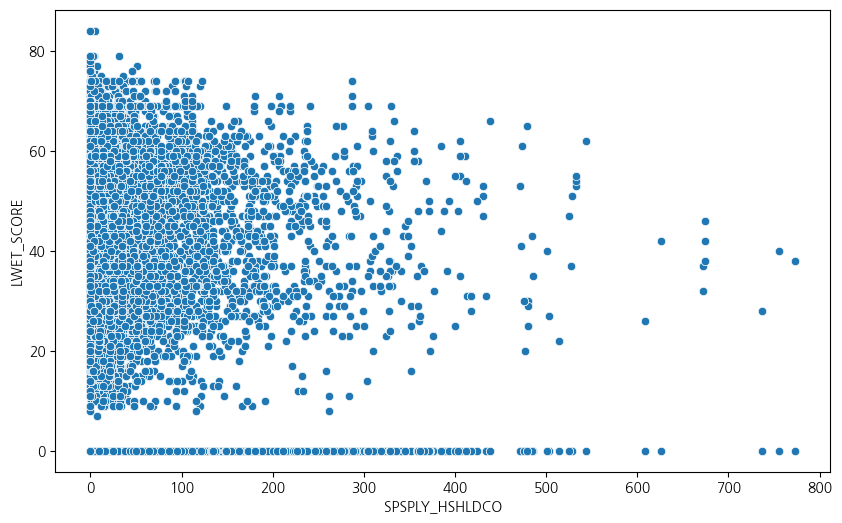

In [20]:
# 특별 공급 개수에 따른 최저 점수 분포
plt.figure(figsize=(10, 6))
sns.scatterplot(data=score_df, x='SPSPLY_HSHLDCO', y='LWET_SCORE')
plt.show()

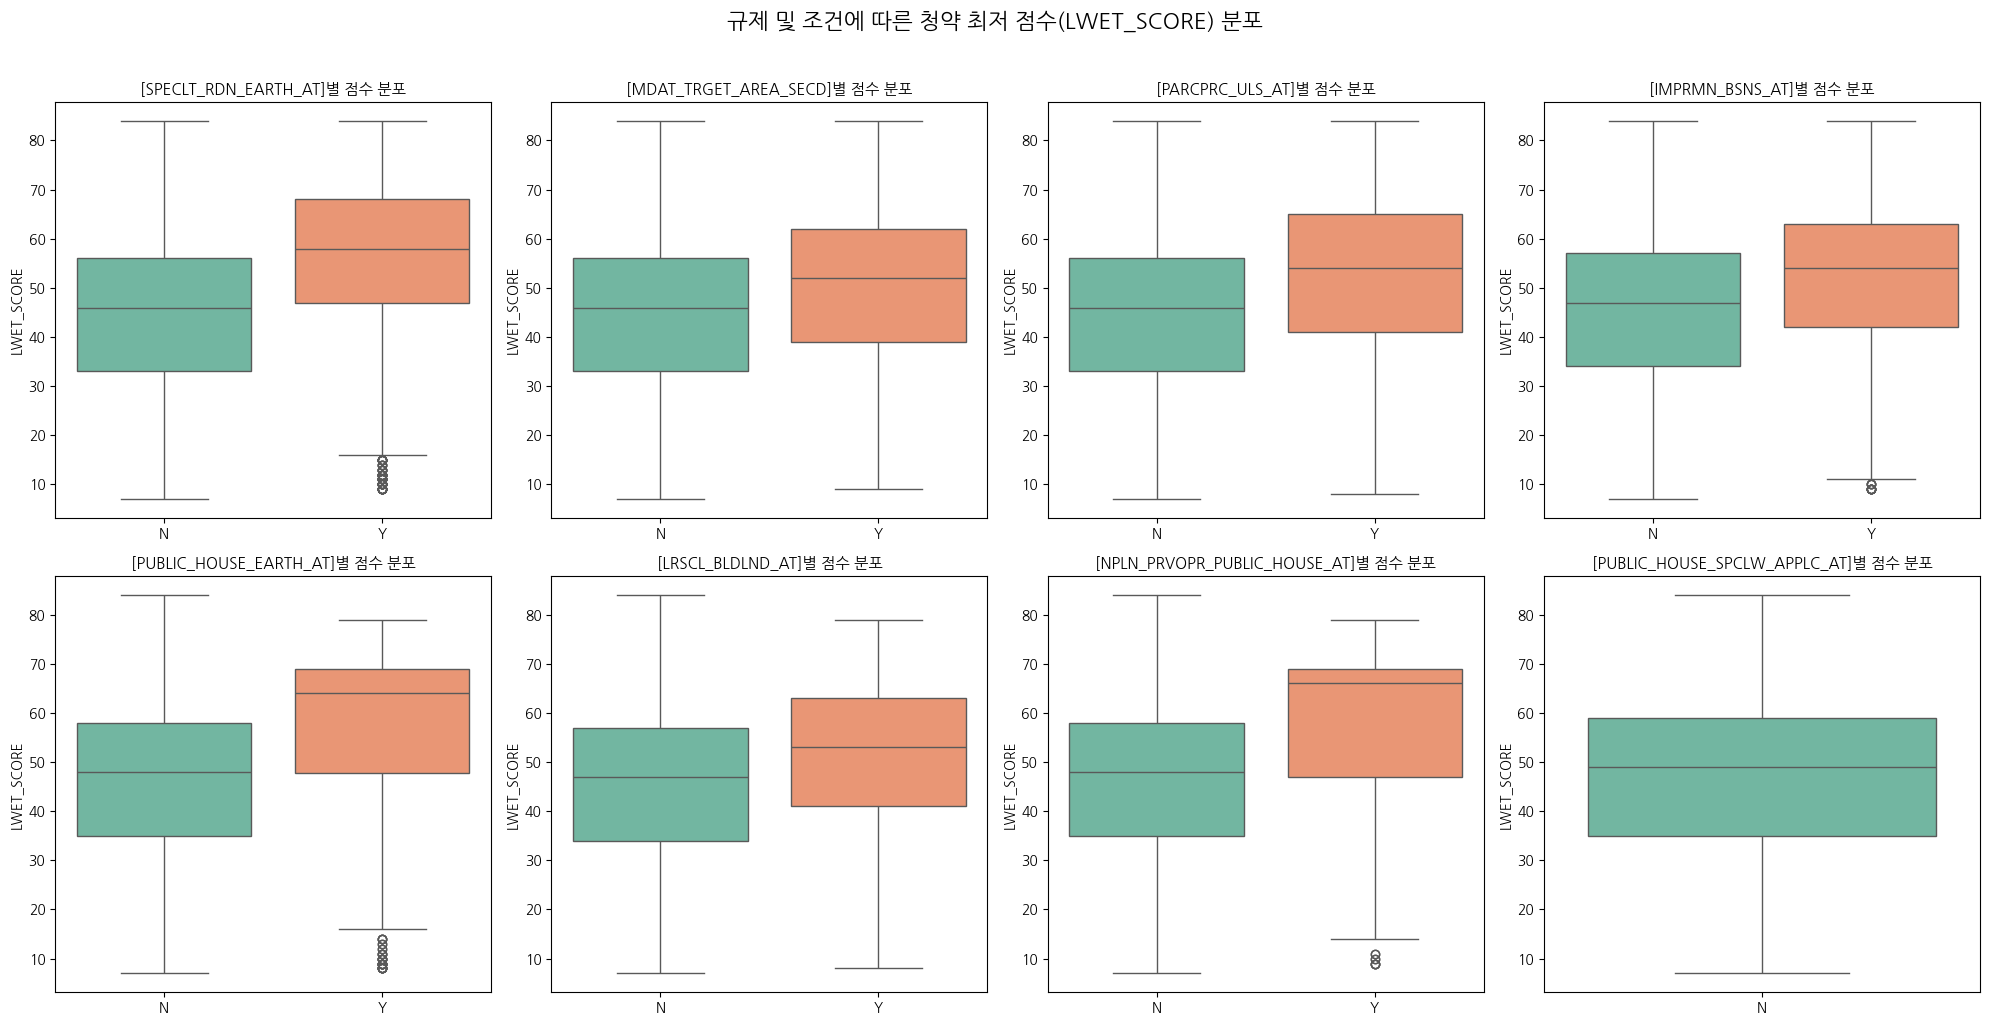

In [21]:
# 규제에 따른 청약 점수 분포
score = 'LWET_SCORE'
regu_t_col = ['SPECLT_RDN_EARTH_AT', 'MDAT_TRGET_AREA_SECD', 'PARCPRC_ULS_AT', 'IMPRMN_BSNS_AT', 'PUBLIC_HOUSE_EARTH_AT', 'LRSCL_BLDLND_AT', 'NPLN_PRVOPR_PUBLIC_HOUSE_AT', 'PUBLIC_HOUSE_SPCLW_APPLC_AT']

regu_t_d = score_df_cmpt_over_1.loc[:, regu_t_col]

for col in regu_t_col:
    regu_t_d[col] = regu_t_d[col].astype('category').cat.codes

# 2. 2행 4열짜리 그래프 창 생성 (크기는 20x10)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()  # 2차원 배열의 축을 1차원으로 펼치기 (반복문용)

# 3. 반복문을 돌며 각 범주형 컬럼별 boxplot 그리기
for i, col in enumerate(regu_t_col):
    sns.boxplot(
        data=score_df_cmpt_over_1,
        x=col,  # X축: 규제 여부 (0/1 또는 범주)
        y=score,  # Y축: 청약 점수 분포
        ax=axes[i],  # 그래프를 그릴 위치 지정
        palette="Set2",
    )
    axes[i].set_title(f"[{col}]별 점수 분포", fontsize=11)
    axes[i].set_xlabel("")  # X축 축이름 생략 (타이틀과 중복 방지)
    axes[i].set_ylabel("LWET_SCORE")

# 4. 레이아웃 정렬 후 출력
plt.suptitle("규제 및 조건에 따른 청약 최저 점수(LWET_SCORE) 분포", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

score_df_cmpt_over_1['REGU_SCORE'] = regu_t_d.sum(axis=1)


<Axes: xlabel='REGU_SCORE', ylabel='LWET_SCORE'>

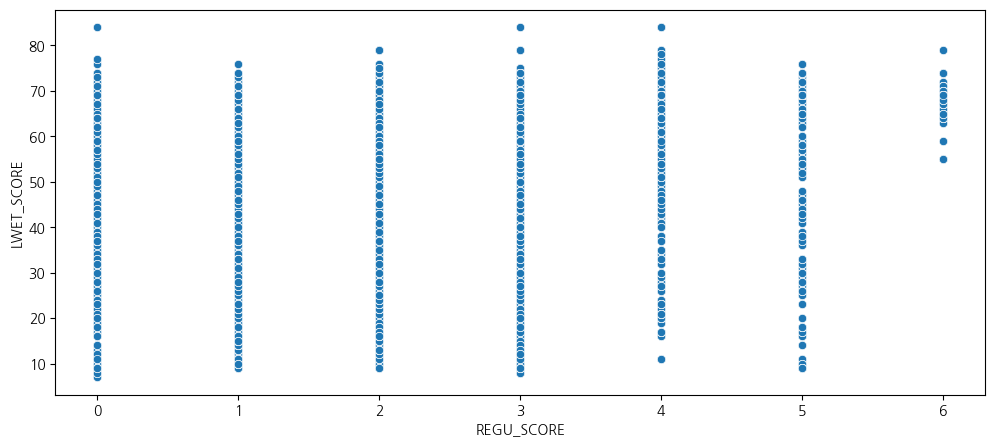

In [22]:
sns.scatterplot(data=score_df_cmpt_over_1, x='REGU_SCORE', y='LWET_SCORE')

<Axes: xlabel='LTTOT_TOP_AMOUNT', ylabel='Count'>

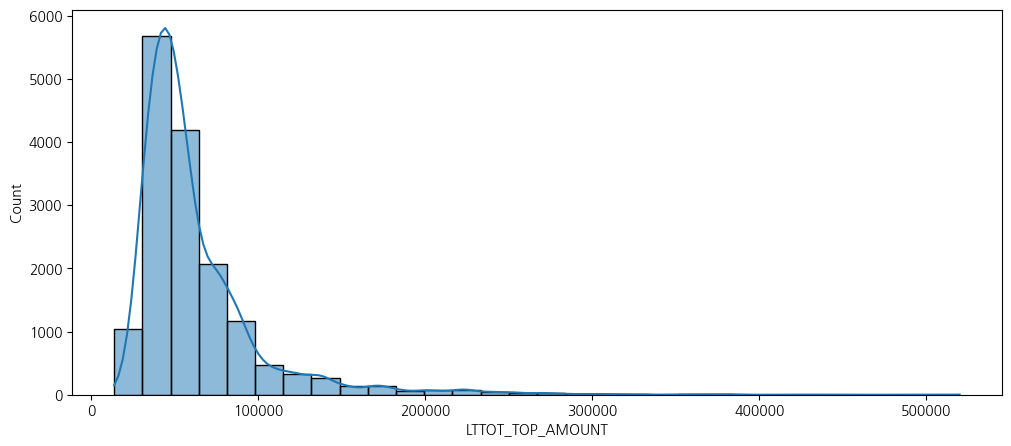

In [23]:
score_df_cmpt_over_1['LTTOT_TOP_AMOUNT_LOG'] = np.log10(score_df_cmpt_over_1['LTTOT_TOP_AMOUNT'] + 1)

sns.histplot(data=score_df_cmpt_over_1, x='LTTOT_TOP_AMOUNT', bins=30, kde=True)

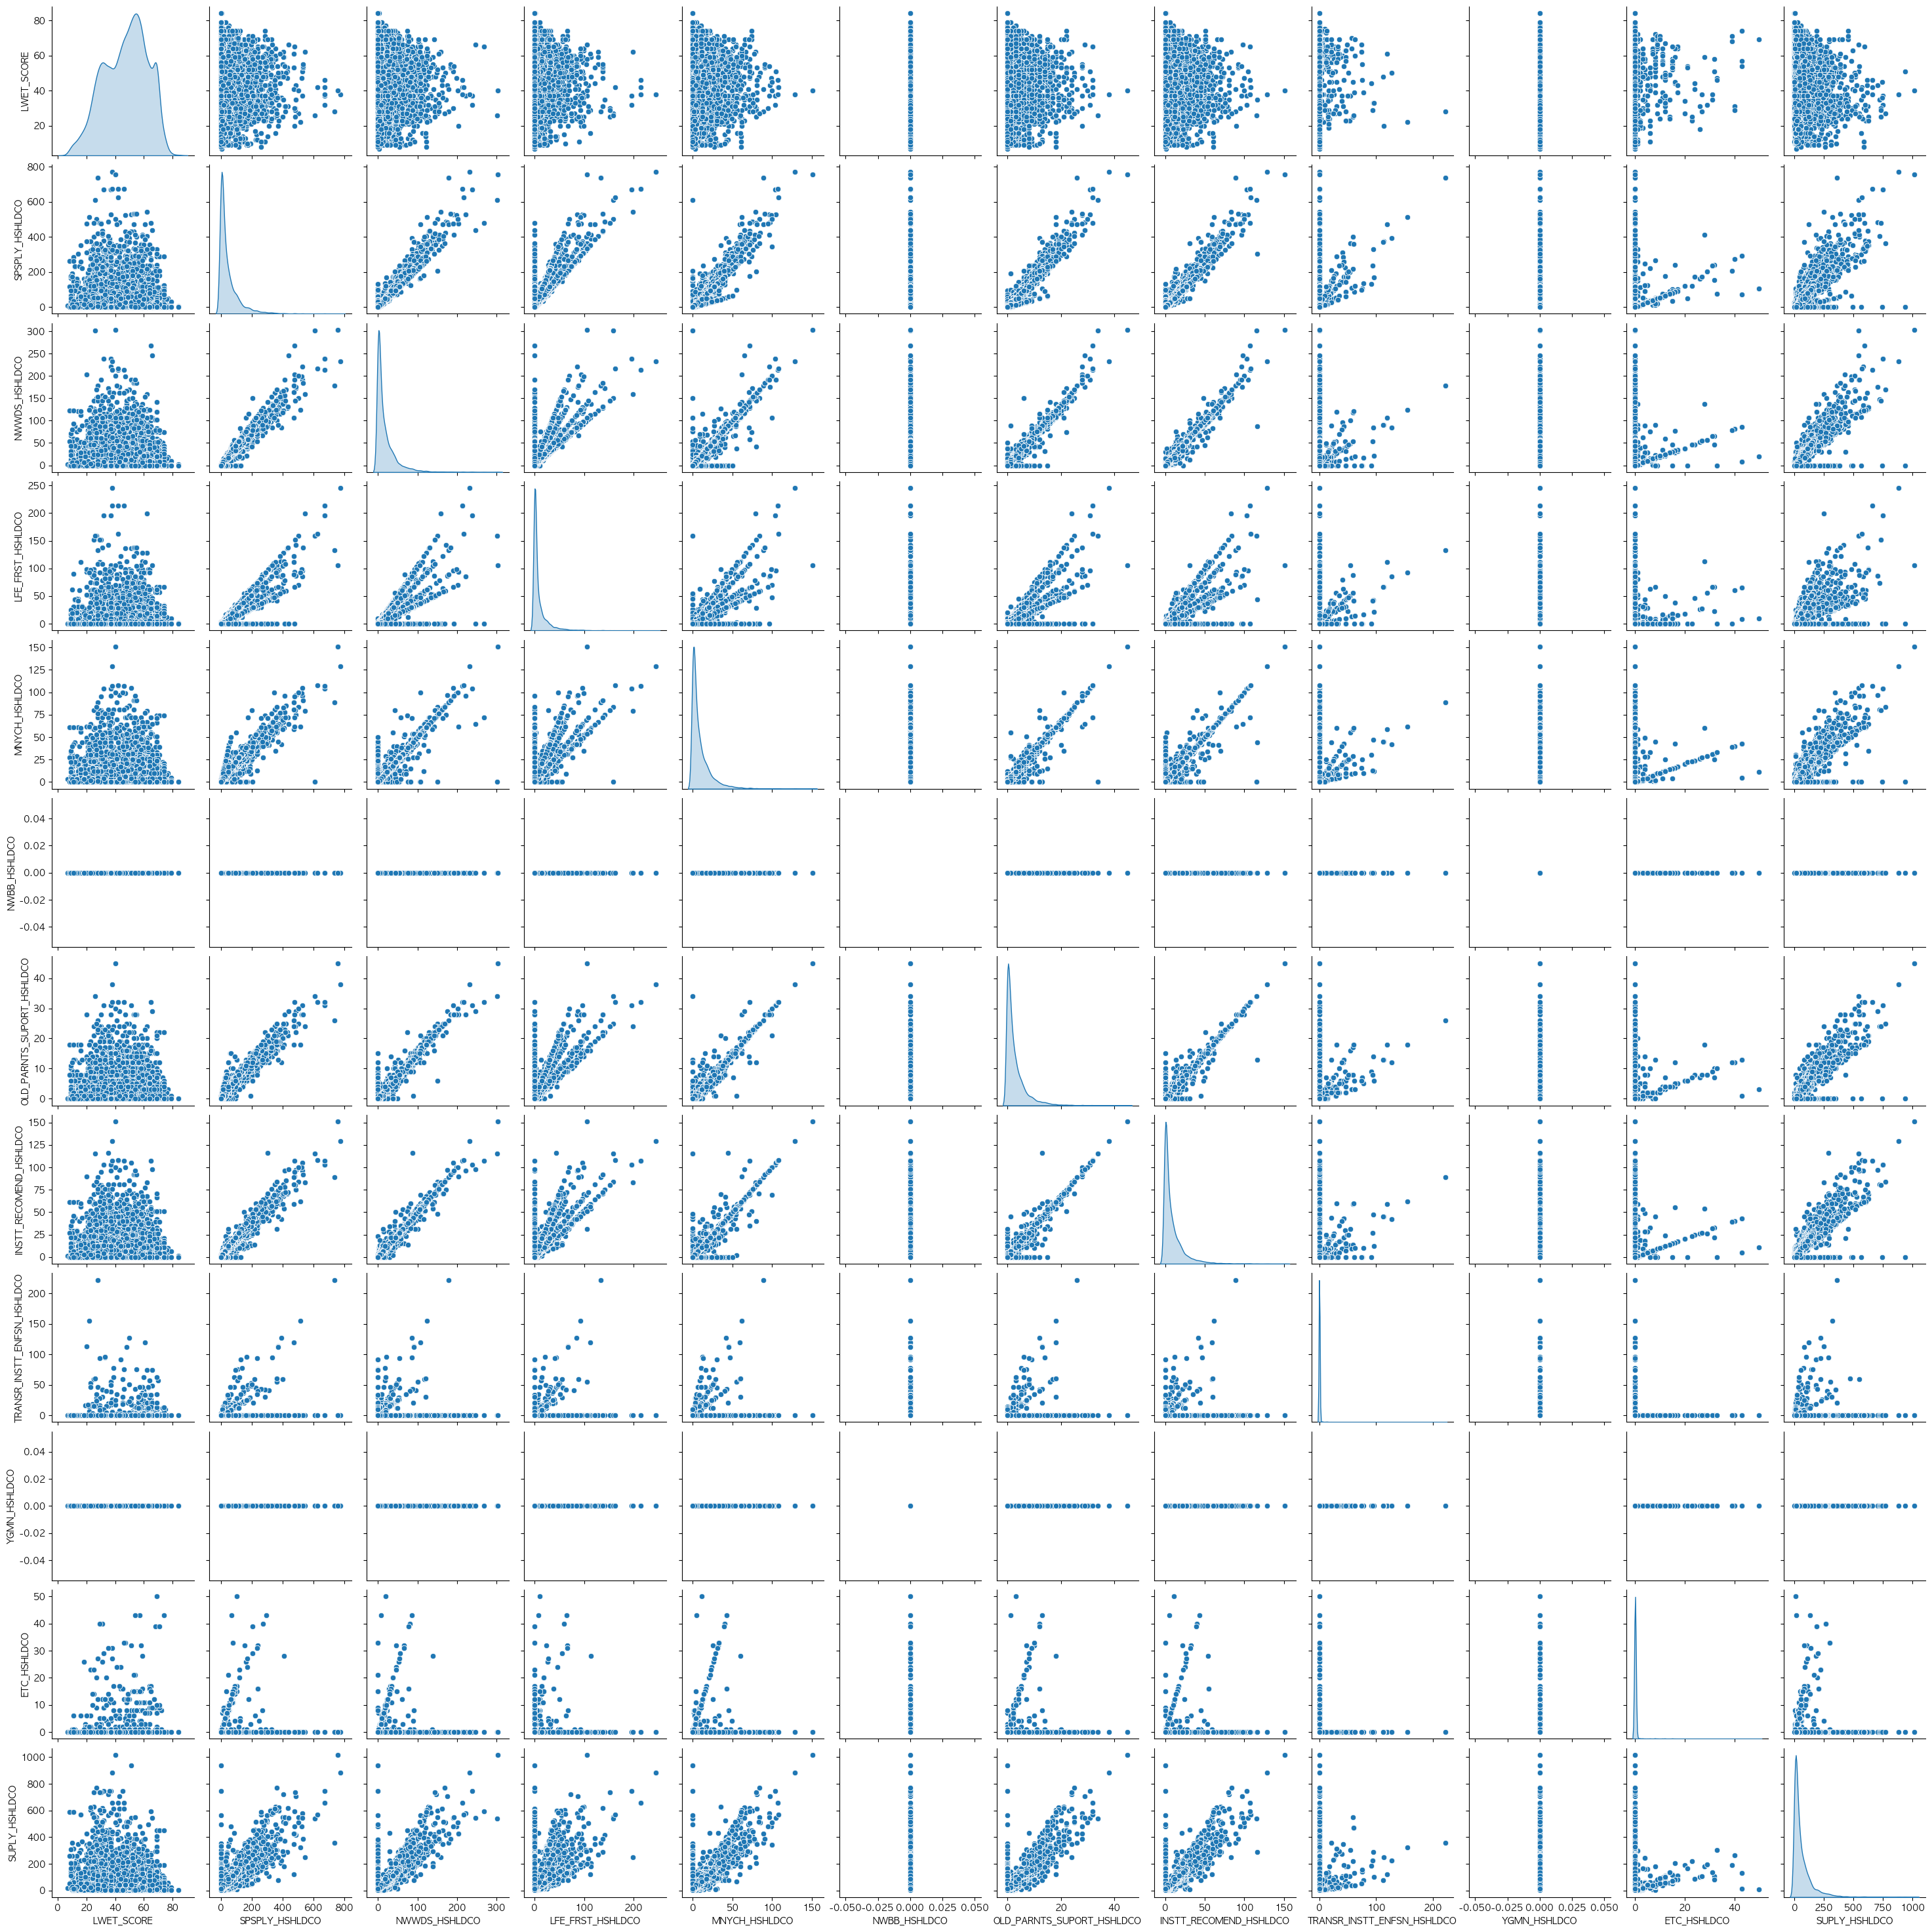

In [25]:
special_sply = [
    'LWET_SCORE',
    'SPSPLY_HSHLDCO',
    'NWWDS_HSHLDCO',
    'LFE_FRST_HSHLDCO',
    'MNYCH_HSHLDCO',
    'NWBB_HSHLDCO',
    'OLD_PARNTS_SUPORT_HSHLDCO',
    'INSTT_RECOMEND_HSHLDCO',
    'TRANSR_INSTT_ENFSN_HSHLDCO',
    'YGMN_HSHLDCO',
    'ETC_HSHLDCO',
    'SUPLY_HSHLDCO'
]

special_sply_df = score_df_cmpt_over_1[special_sply]

sns.pairplot(special_sply_df, diag_kind='kde')\

# 특별 공급이 늘어날수록 합격 커트라인 점수가 낮아짐? 

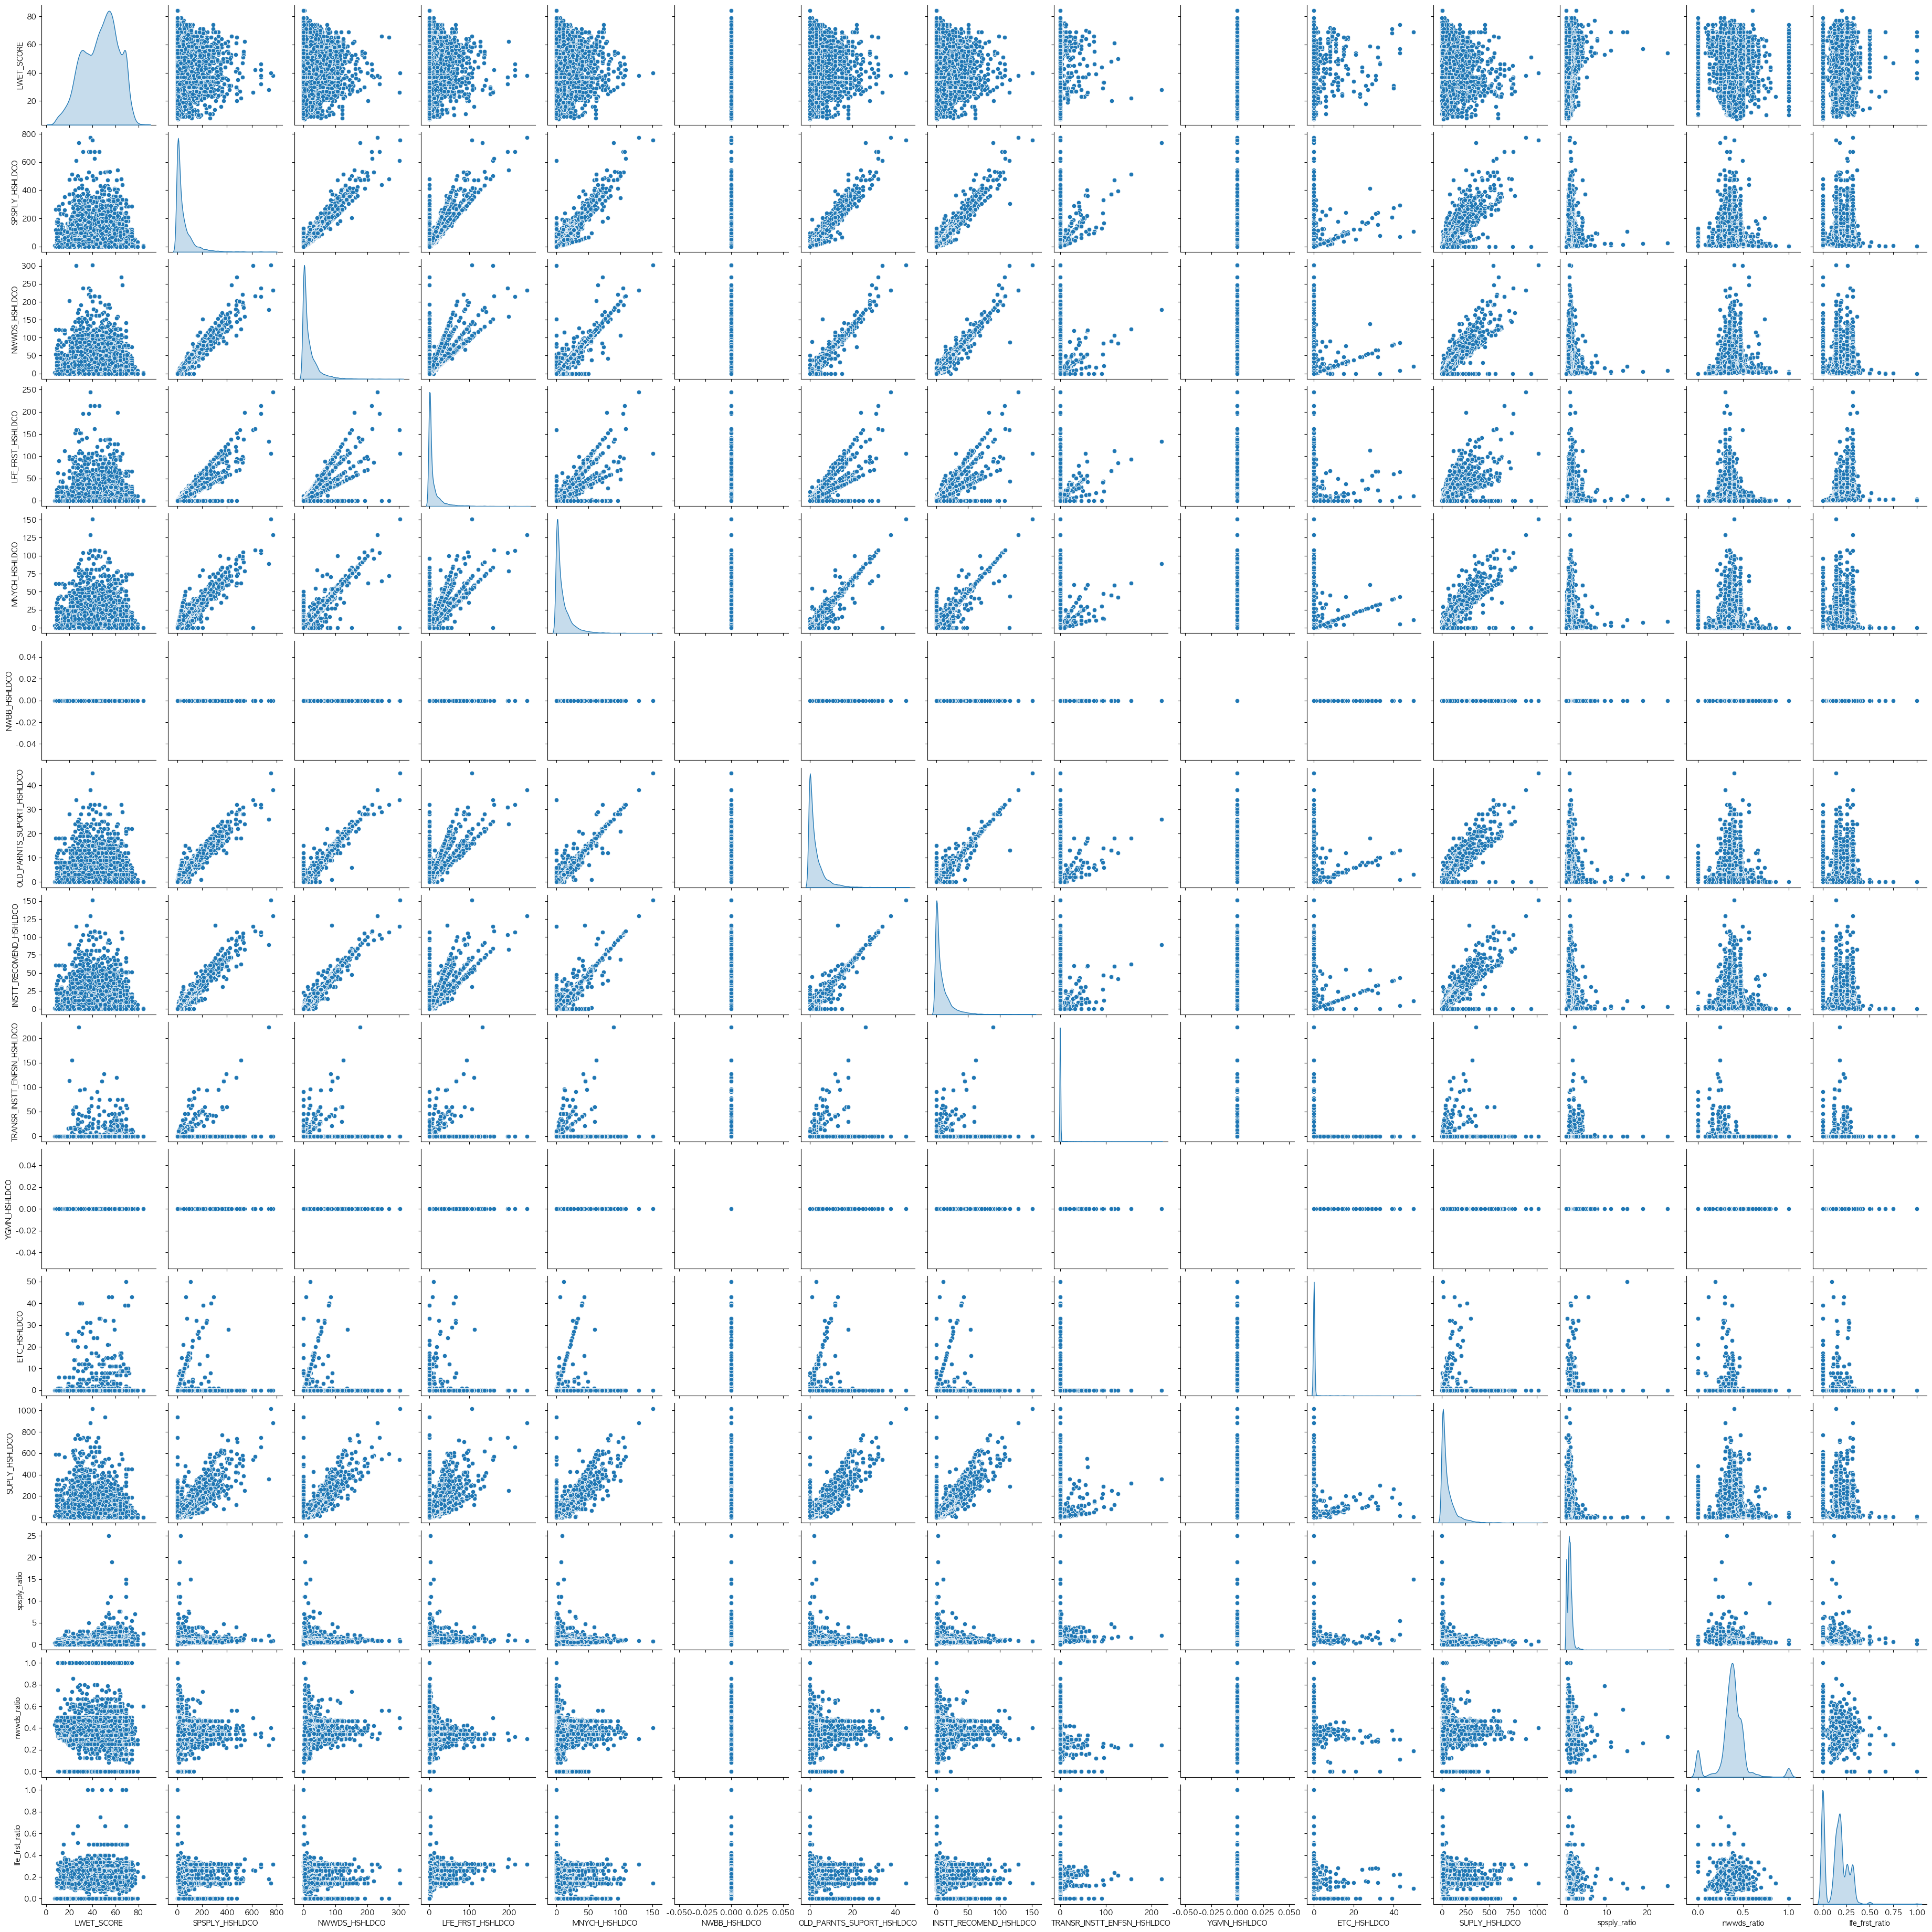

In [130]:
sns.pairplot(special_sply_df, diag_kind='kde')

In [63]:
grp_HSZIP_RESD = score_df_cmpt_over_1.groupby(['HSSPLY_ZIP', 'RESIDE_SENM'])['LWET_SCORE'].mean()
pd.set_option('display.max_rows', None)

grp_HSZIP_RESD_1 = grp_HSZIP_RESD.unstack()
grp_HSZIP_RESD_1.reset_index(inplace=True)
grp_HSZIP_RESD_1.HSSPLY_ZIP = grp_HSZIP_RESD_1.HSSPLY_ZIP.apply(lambda x : '0' + str(x) if len(str(x)) == 4 else str(x))
grp_HSZIP_RESD_1['pre_hszip'] = grp_HSZIP_RESD_1['HSSPLY_ZIP'].astype(str).str[:3]

a = grp_HSZIP_RESD_1.drop('HSSPLY_ZIP', axis=1).groupby('pre_hszip').mean()

# 필요 라이브러리 설치
# pip install folium pgeocode

import folium
import pgeocode
import pandas as pd
import numpy as np
from branca.colormap import LinearColormap

# ── 1. 우편번호 → 위경도 변환 ──────────────────────────────
nomi = pgeocode.Nominatim('kr')

unique_zips = grp_HSZIP_RESD_1['HSSPLY_ZIP'].astype(str).unique()
geo_result = nomi.query_postal_code(unique_zips.tolist())
geo_result['HSSPLY_ZIP'] = unique_zips

# pre_hszip 추가 후 구역별 대표 좌표 계산
geo_result['pre_hszip'] = geo_result['HSSPLY_ZIP'].str[:3]
zip_centroid = (
    geo_result.groupby('pre_hszip')[['latitude', 'longitude']]
              .mean()
              .reset_index()
              .dropna()
)

# ── 2. 점수 데이터와 좌표 병합 ──────────────────────────────
a_reset = a.reset_index()
map_df = a_reset.merge(zip_centroid, on='pre_hszip', how='left') \
                .dropna(subset=['latitude', 'longitude'])

print(f"매핑된 구역: {len(map_df)}개 / 전체 {len(a_reset)}개")

# ── 3. folium 지도 시각화 ────────────────────────────────────
SCORE_COL = '해당지역'   # '기타지역', '기타경기' 로 바꿔서 비교 가능

colormap = LinearColormap(
    colors=['#3182bd', '#fdae61', '#d7191c'],  # 파랑(낮음) → 주황 → 빨강(높음)
    vmin=map_df[SCORE_COL].quantile(0.05),
    vmax=map_df[SCORE_COL].quantile(0.95),
    caption=f'평균 최저 가점 ({SCORE_COL})'
)

m = folium.Map(location=[36.5, 127.8], zoom_start=7, tiles='CartoDB positron')
colormap.add_to(m)

for _, row in map_df.dropna(subset=[SCORE_COL]).iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=9,
        color=colormap(row[SCORE_COL]),
        fill=True,
        fill_color=colormap(row[SCORE_COL]),
        fill_opacity=0.75,
        popup=folium.Popup(
            f"<b>우편 앞 3자리: {row['pre_hszip']}</b><br>"
            f"평균 가점: {row[SCORE_COL]:.1f}점",
            max_width=200
        )
    ).add_to(m)

m.save('score_map.html')
m  # 주피터에서 바로 출력



매핑된 구역: 331개 / 전체 332개


<Axes: xlabel='RESIDE_SENM', ylabel='LWET_SCORE'>

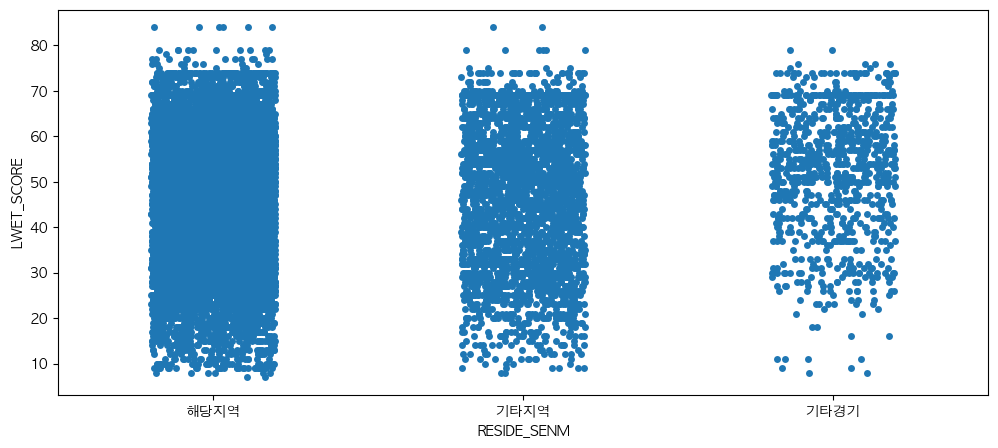

In [42]:
score_df_cmpt_over_1[score_df_cmpt_over_1['RESIDE_SENM'] == '기타경기']['LWET_SCORE']

sns.stripplot(x="RESIDE_SENM", y="LWET_SCORE", data=score_df_cmpt_over_1, jitter=0.2)


In [ ]:
# 2-3. 지역 내 상대 순위 (Kaggle rank normalization 직접 적용)
s = score_df_cmpt_over_1.copy()
s['price_rank_in_region'] = s.groupby('SUBSCRPT_AREA_CODE_NM')['LTTOT_TOP_AMOUNT'] \
                               .transform(lambda x: x.rank(pct=True))

s['cmpet_rank_in_region'] = s.groupby('SUBSCRPT_AREA_CODE_NM')['CMPET_RATE'] \
                               .transform(lambda x: x.rank(pct=True))


s

,CMPET_RATE,HOUSE_MANAGE_NO,HOUSE_TY,MODEL_NO,PBLANC_NO,REQ_CNT,RESIDE_SECD,RESIDE_SENM,SUBSCRPT_RANK_CODE,SUPLY_HSHLDCO,...,OLD_PARNTS_SUPORT_HSHLDCO,SPSPLY_HSHLDCO,SUPLY_AR,TRANSR_INSTT_ENFSN_HSHLDCO,YGMN_HSHLDCO,HOUSE_TY_V1,REGU_SCORE,LTTOT_TOP_AMOUNT_LOG,price_rank_in_region,cmpet_rank_in_region
186,22.000000,2026000115,074.9524A,1,2026000115,22,1,해당지역,1,1,...,0,0,102.3487,0,0,74,0,4.653029,0.684593,0.930233
188,0.000000,2026000115,074.9524A,1,2026000115,0,1,해당지역,2,1,...,0,0,102.3487,0,0,74,0,4.653029,0.684593,0.178779
190,33.782609,2026000115,084.7657A,2,2026000115,777,1,해당지역,1,23,...,1,26,115.6474,0,0,84,0,4.727387,0.920058,0.962209
192,0.000000,2026000115,084.7657A,2,2026000115,0,1,해당지역,2,23,...,1,26,115.6474,0,0,84,0,4.727387,0.920058,0.178779
194,3.833333,2026000115,084.7696B,3,2026000115,46,1,해당지역,1,12,...,0,6,116.1025,0,0,84,0,4.719671,0.905523,0.732558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52138,0.000000,2020000009,074.8900,2,2020000009,0,1,해당지역,2,22,...,1,10,103.1000,0,0,74,0,4.658974,0.392784,0.186503
52140,0.066667,2020000007,084.2405A,1,2020000007,1,1,해당지역,1,15,...,0,0,110.5391,0,0,84,0,4.550241,0.030357,0.360714
52141,0.133333,2020000007,084.2405A,1,2020000007,2,2,기타지역,1,15,...,0,0,110.5391,0,0,84,0,4.550241,0.030357,0.367857
52142,0.333333,2020000007,084.2405A,1,2020000007,5,1,해당지역,2,15,...,0,0,110.5391,0,0,84,0,4.550241,0.030357,0.407143


In [ ]:
score_df_cmpt_over_1['RCRIT_PBLANC_DE'] = pd.to_datetime(df_origin['RCRIT_PBLANC_DE'], errors='coerce')
df_sorted = score_df_cmpt_over_1.sort_values('RCRIT_PBLANC_DE').copy()

# 3-1. 같은 지역의 직전 가점 이력 (time-aware rolling)
df_sorted['region_score_lag1'] = df_sorted.groupby('SUBSCRPT_AREA_CODE_NM')['LWET_SCORE'] \
                                           .transform(lambda x: x.shift(1))

df_sorted['region_score_roll5_mean'] = df_sorted.groupby('SUBSCRPT_AREA_CODE_NM')['LWET_SCORE'] \
                                                 .transform(lambda x: x.shift(1)
                                                            .rolling(5, min_periods=1).mean())

df_sorted['region_score_roll5_std'] = df_sorted.groupby('SUBSCRPT_AREA_CODE_NM')['LWET_SCORE'] \
                                                .transform(lambda x: x.shift(1)
                                                           .rolling(5, min_periods=1).std())

# 3-2. 같은 지역의 직전 경쟁률 이력 (경쟁 트렌드)
df_sorted['region_cmpet_roll3_mean'] = df_sorted.groupby('SUBSCRPT_AREA_CODE_NM')['CMPET_RATE'] \
                                                  .transform(lambda x: x.shift(1)
                                                             .rolling(3, min_periods=1).mean())



KeyError: 'is_top_brand'

## 모델링
- 최저 가점 점수가 존재하는 데이터 기준으로 모델링 수행
- 규제 유/무에 따라 점수 분포가 달라진다. 규제가 있으면 점수가 더 높은 것을 반영하기 위한 피처 상ㅇ
- 유명 브랜드 아파트인 경우 최저 가점이 더 높게 형성됨 -> 반영
- 지역에 따라 점수 분포가 다름 -> 우편번호 앞 3자리로 데이터를 구분 (동 분류)

- 집 유형, 공급량 관련 피처에서는 데이터에서 유의미한 패턴 발견하지 못함 -> 피처 제거


In [18]:
USE_COLUMN = ['COMPET_RATE', 'HOUSE_NM', 'SUBSCRPT_RANK_CODE' , 'RESIDE_SECD', 'SPECLT_RDN_EARTH_AT', 'MDAT_TRGET_AREA_SECD', 'PARCPRC_ULS_AT', 'IMPRMN_BSNS_AT', 'PUBLIC_HOUSE_EARTH_AT', 'LRSCL_BLDLND_AT', 'NPLN_PRVOPR_PUBLIC_HOUSE_AT', 'LTTOT_TOP_AMOUNT']

EXTEND_COLUMN = ['price_rank_in_region', 'cmpet_rank_in_region', 'region_score_lag1', 'region_score_roll5_mean', 'region_score_roll5_std']

df = score_df_cmpt_over_1.sort_values('RCRIT_PBLANC_DE')

brands = ['래미안','힐스테이트','푸르지오','아이파크','자이','e편한세상','더샵','롯데캐슬']

def build_features(df_m):
    df = df_m.copy()
    d = df_m.copy()
    # 로그 변환
    d['log_cmpet_rate']         = np.log1p(df['CMPET_RATE'])
    d['log_lttot_top_amount']   = np.log10(df['LTTOT_TOP_AMOUNT'] + 1)

    # 브랜드 binary
    d['is_top_brand'] = df['HOUSE_NM'].str.contains('|'.join(brands), na=False).astype(int)

    # 규제 플래그 → 0/1
    reg_cols = ['SPECLT_RDN_EARTH_AT','MDAT_TRGET_AREA_SECD','PARCPRC_ULS_AT',
                'IMPRMN_BSNS_AT','PUBLIC_HOUSE_EARTH_AT','LRSCL_BLDLND_AT',
                'NPLN_PRVOPR_PUBLIC_HOUSE_AT']
    for c in reg_cols:
        d[c] = (df[c] == 'Y').astype(int)

    # 평형 숫자 추출
    d['house_area'] = df['HOUSE_TY'].str.extract(r'(\d+)').astype(float)

    # 특별공급 비율
    d['spsply_ratio'] = df['SPSPLY_HSHLDCO'] / df['SUPLY_HSHLDCO'].replace(0, np.nan)

    # 지역 내 상대 순위
    d['price_rank_in_region'] = df.groupby('SUBSCRPT_AREA_CODE_NM')['LTTOT_TOP_AMOUNT'] \
                                  .transform(lambda x: x.rank(pct=True))
    
    d['cmpet_rank_in_region'] = df.groupby('SUBSCRPT_AREA_CODE_NM')['CMPET_RATE'] \
                                  .transform(lambda x: x.rank(pct=True))
    

# 3-2. 같은 지역의 직전 경쟁률 이력 (경쟁 트렌드)
    d['region_cmpet_roll3_mean'] = df.groupby('SUBSCRPT_AREA_CODE_NM')['CMPET_RATE'] \
                                                  .transform(lambda x: x.shift(1)
                                                             .rolling(3, min_periods=1).mean())
    
    d['zipcode_cmpet_mean'] = df.groupby('HSSPLY_ZIP')['CMPET_RATE'].transform('mean')

    d['zipcode_lttot_area_mean'] = df.groupby('HSSPLY_ZIP')['LTTOT_TOP_AMOUNT'].transform('mean')

    # 우체국 번호 앞자리 기준 규제 점수 합
    df['HSSPLY_ZIP_PRE_3'] = df.HSSPLY_ZIP.apply(lambda x: '0' + str(x) if len(str(x)) <= 4 else str(x))
    df['pre_hszip'] = df['HSSPLY_ZIP_PRE_3'].astype(str).str[:3]
    for c in reg_cols:
        df[c] = (df[c] == 'Y').astype(int)
    d['zipcode_regu_score'] = df.groupby('pre_hszip')[reg_cols].transform('sum').sum(axis=1)
    
    
    d['zipcode_lttot_hist_mean'] = (
        df.groupby('pre_hszip')['LTTOT_TOP_AMOUNT']
                     .transform(lambda x: x.shift(1).expanding().mean())
    ).reindex(df.index)

    # 5. 시/군/구 단위 경쟁률 이력 (leakage 방지)
    d['zipcode_cmpet_hist_mean'] = (
        df.groupby('pre_hszip')['CMPET_RATE']
                     .transform(lambda x: x.shift(1).expanding().mean())
    ).reindex(df.index)

    return d


def add_region_lag_features(df):
    d = df.copy()
    pblanc_agg = (
        df.groupby(['PBLANC_NO', 'SUBSCRPT_AREA_CODE_NM', 'RCRIT_PBLANC_DE'])['LWET_SCORE']
          .mean()
          .reset_index()
          .sort_values('RCRIT_PBLANC_DE')
    )
    pblanc_agg['region_score_lag1'] = (
        pblanc_agg.groupby('SUBSCRPT_AREA_CODE_NM')['LWET_SCORE'].shift(1)
    )
    pblanc_agg['region_score_roll5_mean'] = (
        pblanc_agg.groupby('SUBSCRPT_AREA_CODE_NM')['LWET_SCORE']
                  .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )
    pblanc_agg['region_score_roll5_std'] = (
        pblanc_agg.groupby('SUBSCRPT_AREA_CODE_NM')['LWET_SCORE']
                  .transform(lambda x: x.shift(1).rolling(5, min_periods=1).std())
    )
    d = d.merge(
        pblanc_agg.drop(columns=['LWET_SCORE', 'RCRIT_PBLANC_DE']),
        on=['PBLANC_NO', 'SUBSCRPT_AREA_CODE_NM'],
        how='left'
    )
    return d



df_mat = build_features(df)
df_mat = add_region_lag_features(df_mat)


FEATURE_COLS = [
    # 경쟁/수요
    'log_cmpet_rate', 'SUPLY_HSHLDCO', 'spsply_ratio',
    # 청약 구분
    'SUBSCRPT_RANK_CODE', 'RESIDE_SECD',
    # 규제
    'SPECLT_RDN_EARTH_AT','MDAT_TRGET_AREA_SECD','PARCPRC_ULS_AT',
    'IMPRMN_BSNS_AT','PUBLIC_HOUSE_EARTH_AT','LRSCL_BLDLND_AT',
    'NPLN_PRVOPR_PUBLIC_HOUSE_AT',
    # 가격/규모
    'log_lttot_top_amount', 'house_area',
    # 브랜드
    'is_top_brand',
    # 지역 상대값
    'price_rank_in_region', 'cmpet_rank_in_region',
    # 지역 이력 (rolling)
    'region_score_lag1', 'region_score_roll5_mean', 'region_score_roll5_std',
    # 시간
    'notice_year', 'notice_month',
]

TARGET_COL = 'LWET_SCORE'
df_mat.to_csv('../notebooks/train.csv', index=False)
df_mat.head()
X = df_mat[FEATURE_COLS]
# X = X.dropna()
y = df_mat[TARGET_COL]

print('훈련 피처 : ', X.columns.tolist())
display(X.head())
display(X.info())


훈련 피처 :  ['log_cmpet_rate', 'SUPLY_HSHLDCO', 'spsply_ratio', 'SUBSCRPT_RANK_CODE', 'RESIDE_SECD', 'SPECLT_RDN_EARTH_AT', 'MDAT_TRGET_AREA_SECD', 'PARCPRC_ULS_AT', 'IMPRMN_BSNS_AT', 'PUBLIC_HOUSE_EARTH_AT', 'LRSCL_BLDLND_AT', 'NPLN_PRVOPR_PUBLIC_HOUSE_AT', 'log_lttot_top_amount', 'house_area', 'is_top_brand', 'price_rank_in_region', 'cmpet_rank_in_region', 'region_score_lag1', 'region_score_roll5_mean', 'region_score_roll5_std', 'notice_year', 'notice_month']


,log_cmpet_rate,SUPLY_HSHLDCO,spsply_ratio,SUBSCRPT_RANK_CODE,RESIDE_SECD,SPECLT_RDN_EARTH_AT,MDAT_TRGET_AREA_SECD,PARCPRC_ULS_AT,IMPRMN_BSNS_AT,PUBLIC_HOUSE_EARTH_AT,...,log_lttot_top_amount,house_area,is_top_brand,price_rank_in_region,cmpet_rank_in_region,region_score_lag1,region_score_roll5_mean,region_score_roll5_std,notice_year,notice_month
0,0.182322,15,0.000000,2,2,0,0,0,0,0,...,4.550241,84.0,0,0.030357,0.380357,NaN,NaN,NaN,2020,2
1,0.125163,15,0.000000,1,2,0,0,0,0,0,...,4.550241,84.0,0,0.030357,0.367857,NaN,NaN,NaN,2020,2
2,0.064539,15,0.000000,1,1,0,0,0,0,0,...,4.550241,84.0,0,0.030357,0.360714,NaN,NaN,NaN,2020,2
3,0.287682,15,0.000000,2,1,0,0,0,0,0,...,4.550241,84.0,0,0.030357,0.407143,NaN,NaN,NaN,2020,2
4,0.000000,22,0.454545,2,1,0,0,0,0,0,...,4.658974,74.0,0,0.392784,0.186503,NaN,NaN,NaN,2020,2


<class 'pandas.DataFrame'>
RangeIndex: 15810 entries, 0 to 15809
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   log_cmpet_rate               15810 non-null  float64
 1   SUPLY_HSHLDCO                15810 non-null  int64  
 2   spsply_ratio                 15810 non-null  float64
 3   SUBSCRPT_RANK_CODE           15810 non-null  int64  
 4   RESIDE_SECD                  15810 non-null  int64  
 5   SPECLT_RDN_EARTH_AT          15810 non-null  int64  
 6   MDAT_TRGET_AREA_SECD         15810 non-null  int64  
 7   PARCPRC_ULS_AT               15810 non-null  int64  
 8   IMPRMN_BSNS_AT               15810 non-null  int64  
 9   PUBLIC_HOUSE_EARTH_AT        15810 non-null  int64  
 10  LRSCL_BLDLND_AT              15810 non-null  int64  
 11  NPLN_PRVOPR_PUBLIC_HOUSE_AT  15810 non-null  int64  
 12  log_lttot_top_amount         15810 non-null  float64
 13  house_area                 

None

In [26]:
len(df.columns)

50

---
# 모델링 파이프라인

`df_mat[FEATURE_COLS]` 기반 LightGBM 회귀로 `LWET_SCORE` 예측.

## 흐름
1. **시간 기반 Train/Test 분할** (rolling 피처 시간성 보존)
2. **베이스라인 3종** — Mean / Group Mean / Ridge
3. **LightGBM 기본 모델** — TimeSeriesSplit 5-fold CV
4. **Optuna 하이퍼파라미터 튜닝**
5. **최종 Test 평가 + Feature Importance + 잔차 분석**

> Target: `LWET_SCORE` (0~84 정수, 다봉 분포) — 평가: MAE(주) + RMSE(보조)


In [21]:
# ================================================================
# [1] 시간 기반 Train/Test 분할 (80/20) + 평가 함수
# ================================================================
# Why 시간 기반?
#   rolling 피처(region_score_lag1 등)는 "과거 → 현재" 순서 가정.
#   시간 섞이면 leakage 발생.
# Why 2024-01-01 컷?
#   데이터 범위(2020-02 ~ 2026-04)에서 약 80/20 비율.
# ================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

SPLIT_DATE = '2024-01-01'
df_mat['RCRIT_PBLANC_DE'] = pd.to_datetime(df_mat['RCRIT_PBLANC_DE'], errors='coerce')

# RCRIT_PBLANC_DE는 build_features 진입 전 sort_values 됨 → 순서 보존 가정
assert df_mat['RCRIT_PBLANC_DE'].is_monotonic_increasing, \
    "df_mat이 RCRIT_PBLANC_DE 기준 정렬되어 있어야 합니다."

# 분할 마스크
train_mask = df_mat['RCRIT_PBLANC_DE'] <  SPLIT_DATE
test_mask  = df_mat['RCRIT_PBLANC_DE'] >= SPLIT_DATE

X_train = df_mat.loc[train_mask, FEATURE_COLS].reset_index(drop=True)
y_train = df_mat.loc[train_mask, TARGET_COL ].reset_index(drop=True)
X_test  = df_mat.loc[test_mask,  FEATURE_COLS].reset_index(drop=True)
y_test  = df_mat.loc[test_mask,  TARGET_COL ].reset_index(drop=True)


pd.concat([X_train, y_train], axis=1).to_csv('../notebooks/train.csv', index=False)
pd.concat([X_test, y_test], axis=1).to_csv('../notebooks/test.csv', index=False)
train_dates = df_mat.loc[train_mask, 'RCRIT_PBLANC_DE']
test_dates  = df_mat.loc[test_mask,  'RCRIT_PBLANC_DE']

# 분할 검증 (시간 순서 보장)
assert train_dates.max() < pd.Timestamp(SPLIT_DATE), "train에 미래 날짜 포함"
assert test_dates.min() >= pd.Timestamp(SPLIT_DATE), "test에 과거 날짜 포함"

print(f"Train: {len(X_train):>6,}행  ({train_dates.min().date()} ~ {train_dates.max().date()})")
print(f"Test:  {len(X_test):>6,}행  ({test_dates.min().date()} ~ {test_dates.max().date()})")
print(f"비율:  train {len(X_train)/len(df_mat):.1%} / test {len(X_test)/len(df_mat):.1%}")

# Rolling 피처 결측률 (학습 초기엔 정상)
roll_cols = [c for c in ['region_score_lag1','region_score_roll5_mean','region_score_roll5_std'] if c in X_train.columns]
print(f"\nRolling 피처 결측률 (train):")
print(X_train[roll_cols].isna().mean().round(3).to_string())

# ── 평가 함수 ────────────────────────────────────────────────────
results = {}

def evaluate(name: str, y_true, y_pred, store: bool = True):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    print(f"  [{name:28s}] MAE={mae:6.3f}  RMSE={rmse:6.3f}")
    if store:
        results[name] = {'MAE': mae, 'RMSE': rmse}
    return mae, rmse

# CV 객체 (모든 모델에서 재사용)
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)


Train: 12,596행  (2020-02-04 ~ 2023-12-29)
Test:   3,214행  (2024-01-10 ~ 2026-04-17)
비율:  train 79.7% / test 20.3%

Rolling 피처 결측률 (train):
region_score_lag1          0.013
region_score_roll5_mean    0.013
region_score_roll5_std     0.032


In [28]:
# ================================================================
# [2] 베이스라인 3종
# ================================================================
# 모든 모델은 이 베이스라인을 넘어야 의미 있음.
#   B1. Mean         — "아무 정보 없이 평균만"
#   B2. Group Mean   — "거주지×지역만 알면 어디까지?"
#   B3. Ridge        — "선형 관계만으로 어디까지?"
# ================================================================
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

print("=== 베이스라인 3종 (Train → Test) ===\n")

# ── B1. Mean Predictor ──────────────────────────────────────────
y_train_mean = y_train.mean()
pred_b1 = np.full(len(y_test), y_train_mean)
evaluate("B1. Mean Predictor", y_test, pred_b1)

# ── B2. Group Mean (RESIDE_SECD × 지역) ─────────────────────────
# train에서 학습 → test에 매핑. 매핑 실패 시 전체 평균 fallback.
group_keys = ['RESIDE_SECD']
if 'SUBSCRPT_AREA_CODE_NM' in df_mat.columns:
    group_keys.append('SUBSCRPT_AREA_CODE_NM')

train_meta = df_mat.loc[train_mask, group_keys + [TARGET_COL]].reset_index(drop=True)
test_meta  = df_mat.loc[test_mask,  group_keys].reset_index(drop=True)

group_mean = train_meta.groupby(group_keys)[TARGET_COL].mean()
pred_b2 = test_meta.set_index(group_keys).index.map(group_mean)
pred_b2 = pd.Series(pred_b2).fillna(y_train_mean).values
evaluate("B2. Group Mean", y_test, pred_b2)

# ── B3. Ridge ────────────────────────────────────────────────────
# Ridge는 NaN 처리 불가 → median imputer로 채움
# 트리 모델 대비 선형 모델이 어디까지 가능한지 측정
ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('ridge',   Ridge(alpha=1.0, random_state=42))
])
ridge_pipe.fit(X_train, y_train)
pred_b3 = ridge_pipe.predict(X_test)
evaluate("B3. Ridge", y_test, pred_b3)


=== 베이스라인 3종 (Train → Test) ===

  [B1. Mean Predictor          ] MAE=13.283  RMSE=15.403
  [B2. Group Mean              ] MAE=11.381  RMSE=13.356
  [B3. Ridge                   ] MAE= 9.023  RMSE=11.194


(9.02271472895444, 11.193655379812512)

In [30]:
# ================================================================
# [3] LightGBM 기본 모델 + TimeSeriesSplit 5-fold CV
# ================================================================
# Why LightGBM?
#   - 비선형 + 상호작용 + NaN을 한 번에 처리 (rolling 시작 부분 NaN 자동 처리)
#   - 카테고리(RESIDE_SECD 등) 코드값 그대로 사용 가능
#   - Optuna 50 trial × 5-fold = 250회 학습이라 속도 중요
# Why objective='regression_l1' (MAE 직접 최적화)?
#   - target이 다봉 분포 → RMSE 최소화 시 평균값으로 회귀하는 경향
#   - MAE 직접 최적화가 더 robust
# ================================================================
import lightgbm as lgb

# 범주형으로 알려줄 컬럼 (split 시 LGB가 효율적으로 처리)
CATEGORICAL_COLS = [c for c in ['SUBSCRPT_RANK_CODE', 'RESIDE_SECD'] if c in FEATURE_COLS]

base_params = {
    'objective':        'regression_l1',  # MAE 직접 최적화
    'metric':           'mae',
    'learning_rate':    0.05,
    'num_leaves':       31,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq':     5,
    'verbose':          -1,
    'seed':             42,
}

oof_pred   = np.zeros(len(X_train))   # out-of-fold 예측 저장
cv_maes    = []
best_iters = []

print(f"=== LightGBM (default) — {N_SPLITS}-fold TimeSeriesSplit ===\n")

train_meta_dates = df_mat.loc[train_mask, 'RCRIT_PBLANC_DE'].reset_index(drop=True)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    dtr  = lgb.Dataset(X_tr,  label=y_tr,  categorical_feature=CATEGORICAL_COLS)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=CATEGORICAL_COLS, reference=dtr)

    model = lgb.train(
        base_params, dtr,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(0),
        ],
    )

    pred_val = model.predict(X_val, num_iteration=model.best_iteration)
    oof_pred[val_idx] = pred_val

    mae  = mean_absolute_error(y_val, pred_val)
    rmse = float(np.sqrt(mean_squared_error(y_val, pred_val)))
    cv_maes.append(mae)
    best_iters.append(model.best_iteration)

    tr_d  = train_meta_dates.iloc[tr_idx]
    val_d = train_meta_dates.iloc[val_idx]
    print(f"  Fold {fold}: train ~{tr_d.max().date()} | "
          f"val {val_d.min().date()}~{val_d.max().date()} | "
          f"MAE={mae:.3f}  RMSE={rmse:.3f}  best_iter={model.best_iteration}")

print(f"\n  CV MAE 평균: {np.mean(cv_maes):.3f} (±{np.std(cv_maes):.3f})")
print(f"  best_iter 평균: {int(np.mean(best_iters))}")

# ── 전체 Train 학습 → Test 평가 (default 파라미터) ──────────────
mean_best_iter = int(np.mean(best_iters))
dtrain_full = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_COLS)
model_default = lgb.train(
    base_params, dtrain_full,
    num_boost_round=mean_best_iter,
)
pred_test_default = model_default.predict(X_test)
print()
evaluate("M1. LightGBM (default)", y_test, pred_test_default)


=== LightGBM (default) — 5-fold TimeSeriesSplit ===

  Fold 1: train ~2020-07-24 | val 2020-07-24~2021-01-22 | MAE=7.523  RMSE=9.679  best_iter=180
  Fold 2: train ~2021-01-22 | val 2021-01-22~2021-07-09 | MAE=7.557  RMSE=9.980  best_iter=204
  Fold 3: train ~2021-07-09 | val 2021-07-09~2021-12-24 | MAE=5.957  RMSE=8.085  best_iter=369
  Fold 4: train ~2021-12-24 | val 2021-12-24~2022-10-07 | MAE=7.944  RMSE=10.566  best_iter=168
  Fold 5: train ~2022-10-07 | val 2022-10-07~2023-12-29 | MAE=6.325  RMSE=8.215  best_iter=264

  CV MAE 평균: 7.061 (±0.775)
  best_iter 평균: 237

  [M1. LightGBM (default)      ] MAE= 6.302  RMSE= 8.449


(6.302245961761598, 8.4489003746541)

In [32]:
# ================================================================
# [4] Optuna 하이퍼파라미터 튜닝 (TPE + MedianPruner, 50 trial)
# ================================================================
# Why Optuna(TPE)?
#   - Grid: 파라미터 8개 × 각 5값 = 39만 조합 (비현실적)
#   - Random: 좋은 영역 찾아도 그 주변 못 파고듦
#   - TPE: 베이지안 → 좋은 영역 자동 집중
# Why 50 trial?
#   - 데이터 1.6만행 → 과튜닝 위험. 정규화 강도 위주 탐색.
# 정규화 위주 (lambda_l1/l2, min_data_in_leaf, feature/bagging fraction)
# ================================================================
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'objective':        'regression_l1',
        'metric':           'mae',
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':       trial.suggest_int  ('num_leaves', 15, 127),
        'min_data_in_leaf': trial.suggest_int  ('min_data_in_leaf', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq':     trial.suggest_int  ('bagging_freq', 1, 10),
        'lambda_l1':        trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2':        trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
        'verbose':          -1,
        'seed':             42,
    }
    fold_maes = []
    for tr_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        dtr  = lgb.Dataset(X_tr,  label=y_tr,  categorical_feature=CATEGORICAL_COLS)
        dval = lgb.Dataset(X_val, label=y_val, categorical_feature=CATEGORICAL_COLS, reference=dtr)

        m = lgb.train(
            params, dtr,
            num_boost_round=1500,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)],
        )
        pred = m.predict(X_val, num_iteration=m.best_iteration)
        fold_maes.append(mean_absolute_error(y_val, pred))
    return float(np.mean(fold_maes))

study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_warmup_steps=5),
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n  Best CV MAE: {study.best_value:.3f}")
print(f"  Best params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")


  0%|          | 0/50 [00:00<?, ?it/s]


  Best CV MAE: 6.997
  Best params:
    learning_rate: 0.024598574731556182
    num_leaves: 123
    min_data_in_leaf: 70
    feature_fraction: 0.8528307154579591
    bagging_fraction: 0.6477639824328913
    bagging_freq: 6
    lambda_l1: 0.14117812933667864
    lambda_l2: 0.03780027192319317


=== 최종 모델 평가 ===
  [M2. LightGBM (tuned)        ] MAE= 6.233  RMSE= 8.343

=== 전체 결과표 ===
                           MAE    RMSE
B1. Mean Predictor      13.283  15.403
B2. Group Mean          11.381  13.356
B3. Ridge                9.023  11.194
M1. LightGBM (default)   6.302   8.449
M2. LightGBM (tuned)     6.233   8.343


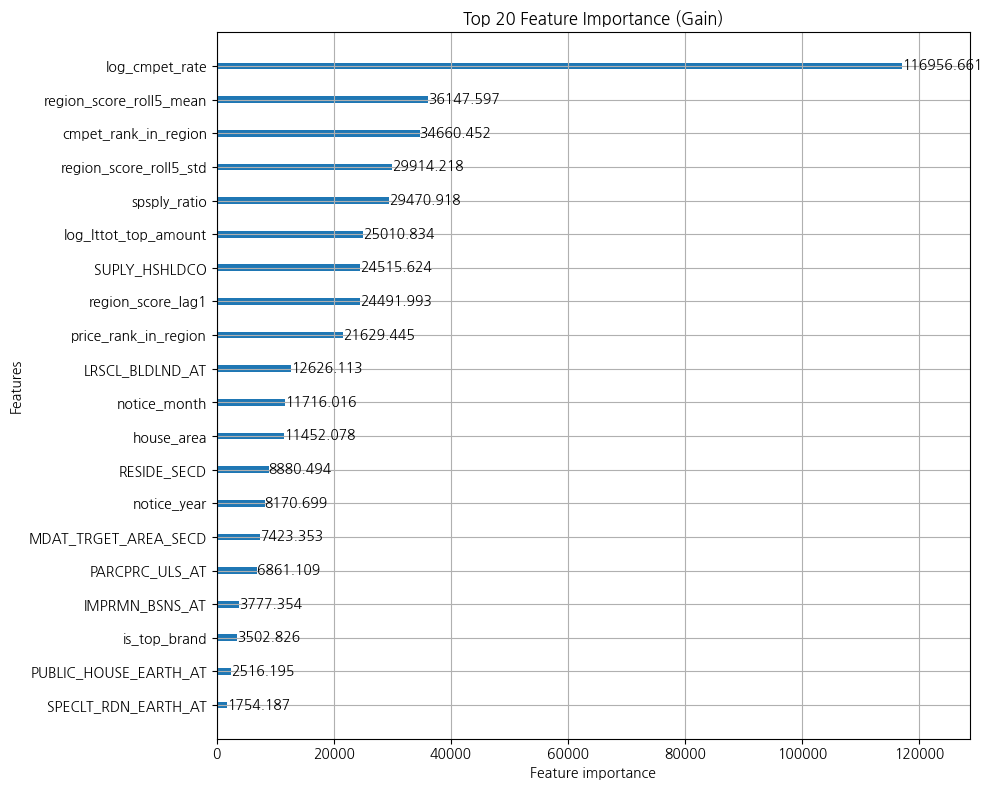

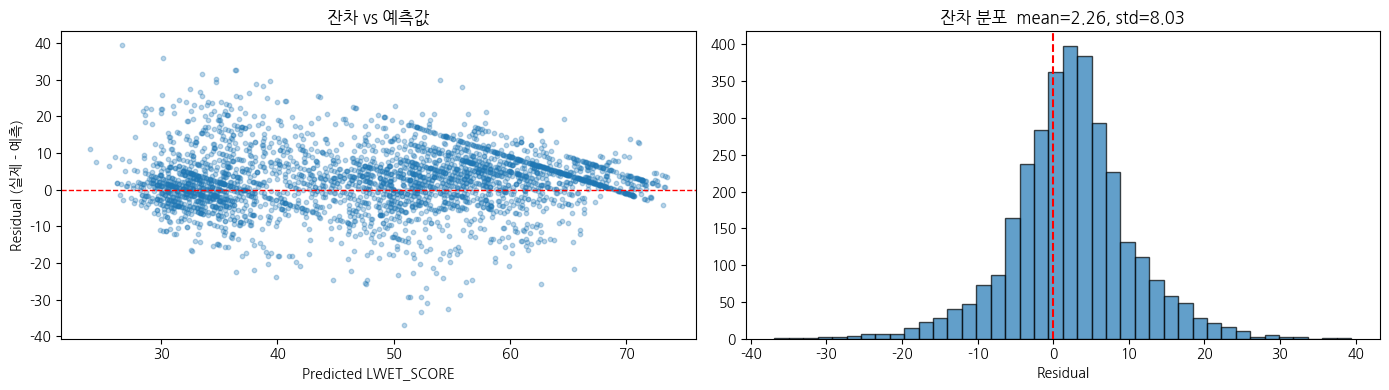


=== 점수 구간별 MAE ===
            n    MAE
bin                 
0-30    316.0  7.623
30-50  1230.0  5.008
50-70  1456.0  6.722
70-84   212.0  7.908


In [33]:
# ================================================================
# [5] 최종 모델 학습 + Test 평가 + Feature Importance + 잔차
# ================================================================
import matplotlib.pyplot as plt

# ── 튜닝 결과로 최종 학습 (튜닝 시 best_iter 다시 추정) ─────────
final_params = {**base_params, **study.best_params}

# 튜닝된 파라미터로 best_iter 재추정 (fold 평균)
final_best_iters = []
for tr_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    dtr  = lgb.Dataset(X_tr,  label=y_tr,  categorical_feature=CATEGORICAL_COLS)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=CATEGORICAL_COLS, reference=dtr)
    m = lgb.train(
        final_params, dtr, num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    final_best_iters.append(m.best_iteration)
final_mean_iter = int(np.mean(final_best_iters))

# 전체 Train으로 최종 학습
dtrain_full = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_COLS)
final_model = lgb.train(
    final_params, dtrain_full,
    num_boost_round=final_mean_iter,
)
pred_test_final = final_model.predict(X_test)

print("=== 최종 모델 평가 ===")
evaluate("M2. LightGBM (tuned)", y_test, pred_test_final)

print("\n=== 전체 결과표 ===")
result_df = pd.DataFrame(results).T.round(3)
print(result_df.to_string())

# ── Feature Importance (Gain 기준) ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
lgb.plot_importance(
    final_model, importance_type='gain',
    max_num_features=20, ax=ax,
)
ax.set_title('Top 20 Feature Importance (Gain)')
plt.tight_layout()
plt.show()

# ── 잔차 분석 ──────────────────────────────────────────────────
# 잔차 = 실제 - 예측 (양수면 과소예측, 음수면 과대예측)
residual = y_test.values - pred_test_final
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(pred_test_final, residual, alpha=0.3, s=10)
axes[0].axhline(0, color='r', linestyle='--', lw=1)
axes[0].set_xlabel('Predicted LWET_SCORE')
axes[0].set_ylabel('Residual (실제 - 예측)')
axes[0].set_title('잔차 vs 예측값')

axes[1].hist(residual, bins=40, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title(f'잔차 분포  mean={residual.mean():.2f}, std={residual.std():.2f}')

plt.tight_layout()
plt.show()

# ── 점수 구간별 MAE (어느 구간이 약점인지 진단) ────────────────
# 다봉 분포에서 모델이 어느 구간을 잘 / 못 맞추는지 확인
bins   = [0, 30, 50, 70, 85]
labels = ['0-30', '30-50', '50-70', '70-84']
y_test_bin = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True)

seg = pd.DataFrame({'y_true': y_test.values, 'y_pred': pred_test_final, 'bin': y_test_bin})
seg_mae = seg.groupby('bin', observed=True).apply(
    lambda g: pd.Series({
        'n':   len(g),
        'MAE': mean_absolute_error(g['y_true'], g['y_pred']) if len(g) else np.nan,
    })
)
print("\n=== 점수 구간별 MAE ===")
print(seg_mae.round(3).to_string())


---
# Stage 1-3: 고급 모델링 (시간·성능 무제약 시나리오)

## 전략 개요
| Stage | 목적 | 모델 |
|---|---|---|
| **1** | 다양한 부스팅 알고리즘 → Stacking | LightGBM(tuned) + CatBoost + XGBoost → Ridge meta |
| **2** | 점예측을 넘어 분포 예측 | Quantile LightGBM (q=0.1 / 0.5 / 0.9) |
| **3** | 사전학습된 Tabular Transformer | TabPFN |

## 공통 원칙
- **모든 OOF는 TimeSeriesSplit 5-fold 기반** → 시간 leakage 방지
- **OOF는 valid_oof_mask로 필터링** (TimeSeriesSplit의 앞부분은 validation에 안 들어감)
- **Stacking meta-learner는 rolling NaN 없는 행만 학습**
- 모든 모델 결과는 `results` dict에 누적되어 마지막에 비교

## 환경
- 로컬: 자동 CPU 모드
- Colab GPU: 자동 감지 → CatBoost/XGBoost/TabPFN GPU 가속


In [34]:
# ================================================================
# [Stage 1-A] 환경 감지 + LightGBM(tuned) OOF 재생성
# ================================================================
# Why OOF 재생성?
#   - 셀 46의 final_model은 전체 train 단일 학습 → fold별 일관성 없음
#   - Stacking에는 fold별 OOF가 필수
#   - Test 예측도 fold별 평균을 써서 CatBoost/XGBoost와 동일한 절차로 통일
# ================================================================
# Colab 환경: 미설치 라이브러리 자동 설치 (로컬에서는 이미 설치돼 있음)
# !pip install -q catboost xgboost  # 필요 시 주석 해제

# GPU 자동 감지
try:
    import torch
    DEVICE_GPU = torch.cuda.is_available()
    DEVICE_STR = 'cuda' if DEVICE_GPU else 'cpu'
except ImportError:
    DEVICE_GPU = False
    DEVICE_STR = 'cpu'
print(f"GPU 사용 가능: {DEVICE_GPU}  (device='{DEVICE_STR}')")

# OOF가 채워진 인덱스만 True (TimeSeriesSplit 첫 fold 앞부분은 validation 미포함)
valid_oof_mask = np.zeros(len(X_train), dtype=bool)
for _, val_idx in tscv.split(X_train):
    valid_oof_mask[val_idx] = True
print(f"OOF 유효 행: {valid_oof_mask.sum():,}/{len(X_train):,}")

# rolling 피처 NaN 마스크 (stacking meta 학습에서 제외할 행)
roll_cols = [c for c in ['region_score_lag1','region_score_roll5_mean','region_score_roll5_std'] if c in X_train.columns]
nan_in_roll = X_train[roll_cols].isna().any(axis=1).values

# ── LightGBM(tuned) OOF + fold별 test 평균 ─────────────────────
oof_lgb_tuned = np.zeros(len(X_train))
test_preds_lgb_tuned = []

print("\n=== Stage 1-A: LightGBM (tuned) ===")
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    dtr  = lgb.Dataset(X_tr,  label=y_tr,  categorical_feature=CATEGORICAL_COLS)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=CATEGORICAL_COLS, reference=dtr)

    m = lgb.train(
        final_params, dtr, num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    oof_lgb_tuned[val_idx] = m.predict(X_val, num_iteration=m.best_iteration)
    test_preds_lgb_tuned.append(m.predict(X_test, num_iteration=m.best_iteration))
    print(f"  Fold {fold}: MAE={mean_absolute_error(y_val, oof_lgb_tuned[val_idx]):.3f}  iter={m.best_iteration}")

pred_test_lgb_tuned = np.mean(test_preds_lgb_tuned, axis=0)
print(f"\n  LGB tuned OOF MAE: {mean_absolute_error(y_train[valid_oof_mask], oof_lgb_tuned[valid_oof_mask]):.3f}")
evaluate("M2b. LightGBM tuned (fold-avg)", y_test, pred_test_lgb_tuned)


GPU 사용 가능: True  (device='cuda')
OOF 유효 행: 10,495/12,596

=== Stage 1-A: LightGBM (tuned) ===
  Fold 1: MAE=7.350  iter=222
  Fold 2: MAE=7.406  iter=756
  Fold 3: MAE=5.859  iter=414
  Fold 4: MAE=8.029  iter=270
  Fold 5: MAE=6.332  iter=636

  LGB tuned OOF MAE: 6.995
  [M2b. LightGBM tuned (fold-avg)] MAE= 6.423  RMSE= 8.454


(6.423368546805917, 8.453720827575887)

In [35]:
# ================================================================
# [Stage 1-C] XGBoost OOF + Test
# ================================================================
# Why XGBoost?
#   - level-wise tree (LGB와 다른 성장 방식) → 또 다른 편향
#   - GPU 가속 (device='cuda', tree_method='hist')
#   - reg:absoluteerror로 MAE 직접 최적화
# ================================================================
import xgboost as xgb

xgb_params = {
    'objective':         'reg:absoluteerror',  # MAE
    'tree_method':       'hist',
    'device':            DEVICE_STR,           # 'cuda' or 'cpu'
    'learning_rate':     0.05,
    'max_depth':         6,
    'subsample':         0.9,
    'colsample_bytree':  0.9,
    'min_child_weight':  5,
    'reg_lambda':        1.0,
    'reg_alpha':         0.5,
    'seed':              42,
    'verbosity':         0,
}

oof_xgb = np.zeros(len(X_train))
test_preds_xgb = []
best_iters_xgb = []

print("=== Stage 1-C: XGBoost ===")
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    dtr  = xgb.DMatrix(X_tr,  label=y_tr)
    dval = xgb.DMatrix(X_val, label=y_val)

    m = xgb.train(
        xgb_params, dtr,
        num_boost_round=3000,
        evals=[(dval, 'val')],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    iter_range = (0, m.best_iteration + 1)
    oof_xgb[val_idx] = m.predict(dval, iteration_range=iter_range)
    test_preds_xgb.append(m.predict(xgb.DMatrix(X_test), iteration_range=iter_range))
    best_iters_xgb.append(m.best_iteration)
    print(f"  Fold {fold}: MAE={mean_absolute_error(y_val, oof_xgb[val_idx]):.3f}  iter={m.best_iteration}")

pred_test_xgb = np.mean(test_preds_xgb, axis=0)
print(f"\n  XGBoost OOF MAE: {mean_absolute_error(y_train[valid_oof_mask], oof_xgb[valid_oof_mask]):.3f}")
evaluate("M4. XGBoost", y_test, pred_test_xgb)


=== Stage 1-C: XGBoost ===
  Fold 1: MAE=7.888  iter=243
  Fold 2: MAE=7.531  iter=375
  Fold 3: MAE=6.111  iter=310
  Fold 4: MAE=8.014  iter=187
  Fold 5: MAE=6.306  iter=639

  XGBoost OOF MAE: 7.170
  [M4. XGBoost                 ] MAE= 6.577  RMSE= 8.539


(6.5772202894712875, 8.539353510436781)

In [ ]:
# ================================================================
# [Stage 1-D] Stacking — LGB(tuned) + CatBoost + XGBoost → Ridge meta
# ================================================================
# Why Stacking?
#   - 세 모델은 서로 다른 split 알고리즘 → 다른 실수 패턴 → 보완적
# Why Ridge meta?
#   - L1 OOF는 동일 스케일(LWET_SCORE 단위) → 단순 가중합으로 충분
#   - 작은 정규화로 가중치 안정화 (각 모델의 신뢰도 자동 학습)
# 핵심: meta 학습에 valid_oof_mask + rolling NaN 제거된 행만 사용
#       (그 외 행을 쓰면 0이나 NaN으로 가중치가 망가짐)
# ================================================================
stack_X    = np.column_stack([oof_lgb_tuned, oof_xgb])
stack_test = np.column_stack([pred_test_lgb_tuned, pred_test_xgb])

# 더블 필터: (1) OOF 채워진 행 (2) rolling NaN 없는 행
good = valid_oof_mask & ~nan_in_roll
print(f"meta 학습 행: {good.sum():,}/{len(X_train):,}")

meta = Ridge(alpha=1.0, random_state=42)
meta.fit(stack_X[good], y_train[good])

print(f"\n  Meta 가중치:")
for name, w in zip(['LGB(tuned)','XGBoost'], meta.coef_):
    print(f"    {name:12s}: {w:+.3f}")
print(f"  Intercept: {meta.intercept_:.3f}")

pred_test_stack = meta.predict(stack_test)
print()
evaluate("M5. Stacking (LGB+XGB)", y_test, pred_test_stack)

# Stacking 진단: 단일 모델 대비 개선 여부
single_best = min(results['M2b. LightGBM tuned (fold-avg)']['MAE'],
                  results['M4. XGBoost']['MAE'])
gain = single_best - results['M5. Stacking (LGB+XGB)']['MAE']
print(f"\n  단일 최고 대비 stacking 개선: {gain:+.3f} MAE")


meta 학습 행: 10,339/12,596

  Meta 가중치:
    LGB(tuned)  : +0.796
    XGBoost     : +0.215
  Intercept: -1.571

  [M5. Stacking (LGB+Cat+XGB)  ] MAE= 6.756  RMSE= 8.739


KeyError: 'M5. Stacking (LGB+XGB)'

=== Stage 2: Quantile LightGBM ===
  q=0.1: avg best_iter=131
  q=0.5: avg best_iter=222
  q=0.9: avg best_iter=191
  [M6. Quantile LGB (q=0.5)    ] MAE= 6.505  RMSE= 8.510

  80% 신뢰구간 coverage: 68.0%  (이상치: 80%)
  평균 구간 폭: 20.7점
  → coverage > 80%면 구간이 보수적, < 80%면 과소 추정


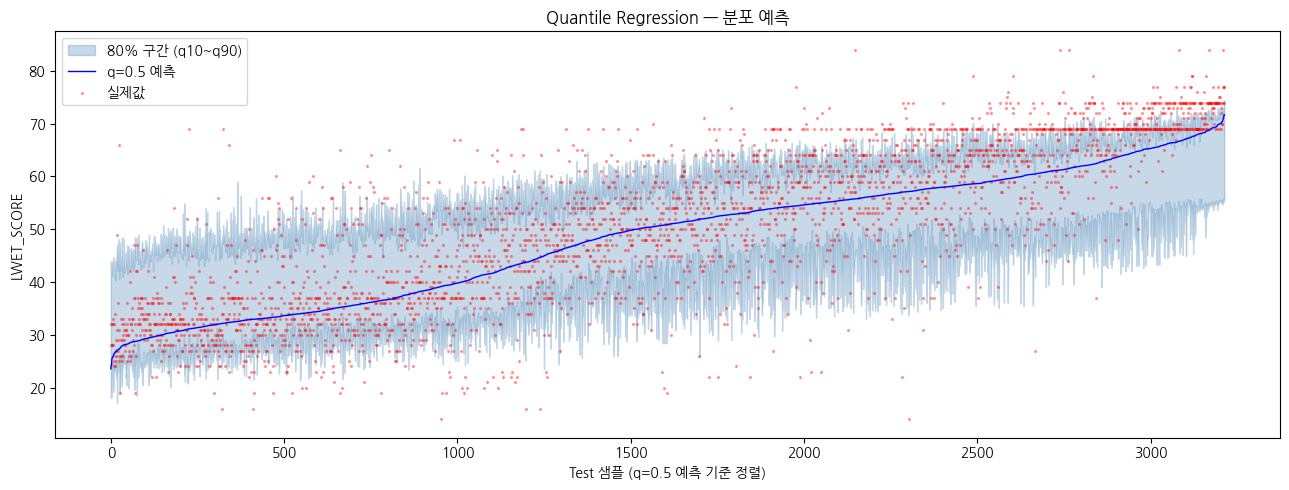

In [38]:
# ================================================================
# [Stage 2] Quantile LightGBM — 분포 예측 (q=0.1 / 0.5 / 0.9)
# ================================================================
# Why Quantile?
#   - 점예측("65점")보다 구간("52~68점, 80% 확률")이 실무 가치 큼
#   - 청약 전략: "내 점수 60점인데 안전한가?"에 직접 답 가능
# Why 3개 분위수만?
#   - q=0.5: 중앙 예측 (MAE 최적과 거의 일치)
#   - q=0.1, q=0.9: 80% 신뢰구간
#   - q=0.05/0.95로 확장하면 95% 구간도 가능
# ================================================================
import matplotlib.pyplot as plt

print("=== Stage 2: Quantile LightGBM ===")
quantile_test_preds = {}

for alpha in [0.1, 0.5, 0.9]:
    qparams = {**base_params, 'objective': 'quantile', 'alpha': alpha, 'metric': 'quantile'}

    fold_iters = []
    fold_test_preds = []
    for tr_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        dtr  = lgb.Dataset(X_tr,  label=y_tr,  categorical_feature=CATEGORICAL_COLS)
        dval = lgb.Dataset(X_val, label=y_val, categorical_feature=CATEGORICAL_COLS, reference=dtr)
        m = lgb.train(qparams, dtr, num_boost_round=2000,
                      valid_sets=[dval],
                      callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
        fold_iters.append(m.best_iteration)
        fold_test_preds.append(m.predict(X_test, num_iteration=m.best_iteration))

    quantile_test_preds[alpha] = np.mean(fold_test_preds, axis=0)
    print(f"  q={alpha:.1f}: avg best_iter={int(np.mean(fold_iters))}")

pred_q10 = quantile_test_preds[0.1]
pred_q50 = quantile_test_preds[0.5]
pred_q90 = quantile_test_preds[0.9]

evaluate("M6. Quantile LGB (q=0.5)", y_test, pred_q50)

# 신뢰구간 평가
coverage = ((pred_q10 <= y_test.values) & (y_test.values <= pred_q90)).mean()
interval_width = (pred_q90 - pred_q10).mean()
print(f"\n  80% 신뢰구간 coverage: {coverage:.1%}  (이상치: 80%)")
print(f"  평균 구간 폭: {interval_width:.1f}점")
print(f"  → coverage > 80%면 구간이 보수적, < 80%면 과소 추정")

# ── 시각화: 예측 + 신뢰구간 ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
sort_idx = np.argsort(pred_q50)
xs = np.arange(len(y_test))
ax.fill_between(xs, pred_q10[sort_idx], pred_q90[sort_idx], alpha=0.3, color='steelblue', label='80% 구간 (q10~q90)')
ax.plot(xs, pred_q50[sort_idx], 'b-', lw=1, label='q=0.5 예측')
ax.scatter(xs, y_test.values[sort_idx], c='red', s=2, alpha=0.3, label='실제값')
ax.set_xlabel('Test 샘플 (q=0.5 예측 기준 정렬)')
ax.set_ylabel('LWET_SCORE')
ax.set_title('Quantile Regression — 분포 예측')
ax.legend()
plt.tight_layout()
plt.show()


=== 전체 모델 비교 (MAE 오름차순) ===

                                   MAE    RMSE
M2. LightGBM (tuned)             6.233   8.343
M1. LightGBM (default)           6.302   8.449
M2b. LightGBM tuned (fold-avg)   6.423   8.454
M6. Quantile LGB (q=0.5)         6.505   8.510
M4. XGBoost                      6.577   8.539
M5. Stacking (LGB+Cat+XGB)       6.756   8.739
B3. Ridge                        9.023  11.194
B2. Group Mean                  11.381  13.356
B1. Mean Predictor              13.283  15.403

🏆 최고 모델: M2. LightGBM (tuned)
   Test MAE:  6.233
   Test RMSE: 8.343
   Mean 베이스라인 대비 개선: 53.1%
   Ridge 베이스라인 대비 개선: 30.9%


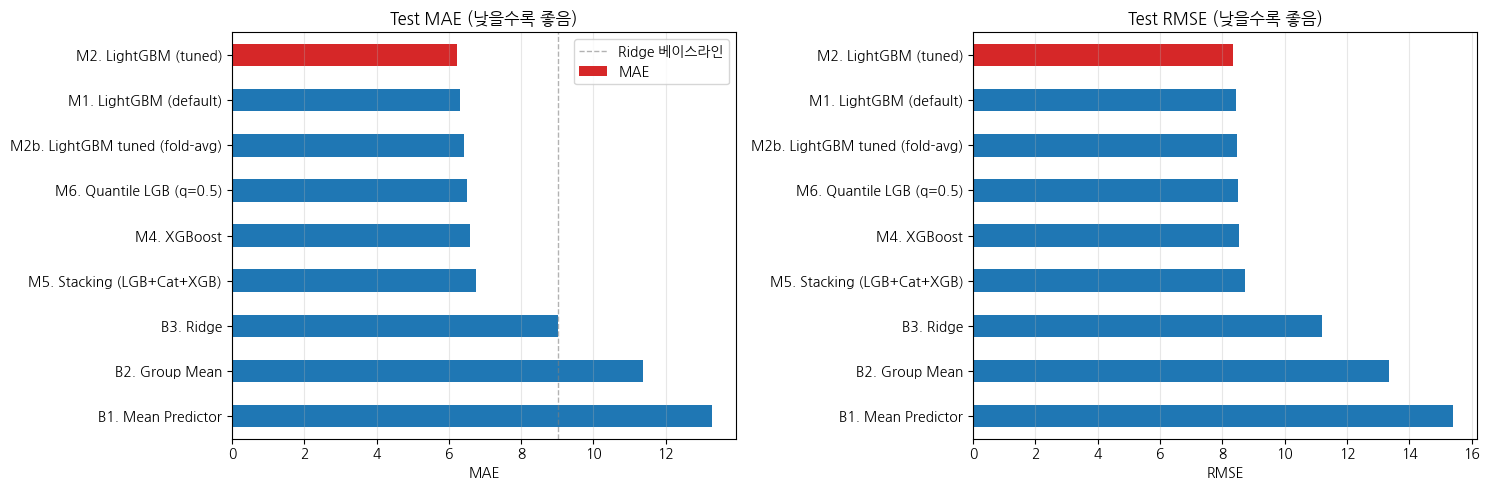


=== M2. LightGBM (tuned) — 점수 구간별 MAE ===
            n    MAE
bin                 
0-30    316.0  8.301
30-50  1230.0  5.567
50-70  1456.0  6.471
70-84   212.0  8.268


In [39]:
# ================================================================
# [최종] 모든 모델 비교 + 최고 모델 선택 + 시각화
# ================================================================
import matplotlib.pyplot as plt

result_df = pd.DataFrame(results).T.sort_values('MAE')
print("=== 전체 모델 비교 (MAE 오름차순) ===\n")
print(result_df.round(3).to_string())

best_name = result_df.index[0]
best_mae  = result_df.iloc[0]['MAE']
baseline_mae = result_df.loc['B1. Mean Predictor', 'MAE']

print(f"\n🏆 최고 모델: {best_name}")
print(f"   Test MAE:  {best_mae:.3f}")
print(f"   Test RMSE: {result_df.iloc[0]['RMSE']:.3f}")
print(f"   Mean 베이스라인 대비 개선: {(1 - best_mae/baseline_mae)*100:.1f}%")
print(f"   Ridge 베이스라인 대비 개선: {(1 - best_mae/result_df.loc['B3. Ridge','MAE'])*100:.1f}%")

# ── 시각화 ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, max(5, len(result_df)*0.4)))
colors = ['#d62728' if c == best_name else '#1f77b4' for c in result_df.index]

result_df['MAE'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].invert_yaxis()
axes[0].set_xlabel('MAE')
axes[0].set_title('Test MAE (낮을수록 좋음)')
axes[0].axvline(result_df.loc['B3. Ridge', 'MAE'], color='gray', ls='--', lw=1, alpha=0.6, label='Ridge 베이스라인')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

result_df['RMSE'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].invert_yaxis()
axes[1].set_xlabel('RMSE')
axes[1].set_title('Test RMSE (낮을수록 좋음)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ── 점수 구간별 MAE: 최고 모델의 약점 진단 ─────────────────────
# 최고 모델의 test 예측 추적
best_preds_map = {
    'M2b. LightGBM tuned (fold-avg)': 'pred_test_lgb_tuned',
    'M3. CatBoost':                   'pred_test_cat',
    'M4. XGBoost':                    'pred_test_xgb',
    'M5. Stacking (LGB+Cat+XGB)':     'pred_test_stack',
    'M6. Quantile LGB (q=0.5)':       'pred_q50',
    'M7. TabPFN':                     'pred_test_tabpfn',
}
best_pred = globals().get(best_preds_map.get(best_name, 'pred_test_lgb_tuned'))

if best_pred is not None:
    bins = [0, 30, 50, 70, 85]
    labels = ['0-30', '30-50', '50-70', '70-84']
    y_test_bin = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True)
    seg = pd.DataFrame({'y_true': y_test.values, 'y_pred': best_pred, 'bin': y_test_bin})
    seg_stat = seg.groupby('bin', observed=True).apply(
        lambda g: pd.Series({'n': len(g), 'MAE': mean_absolute_error(g['y_true'], g['y_pred']) if len(g) else np.nan})
    )
    print(f"\n=== {best_name} — 점수 구간별 MAE ===")
    print(seg_stat.round(3).to_string())


---
# 고급 모델링 — Hurdle Model + 구간별 전용 모델

## V2 실패 진단
이전 V2(TE + Seed Avg + Stacking)는 단일 LGB tuned(6.233)를 못 이김.
- TE가 rolling 피처와 정보 중복 → 노이즈로 작용
- 30 trial 튜닝이 V2 피처로 overfit
- 세 부스팅 모델의 다양성 부족 → stacking 효과 없음

## 새 접근 — 데이터 특성에 맞춘 모델 분해
**V1과 다른 방향**: 단일 회귀 모델의 한계를 데이터 분해로 극복.

### A. Hurdle Model
- **0점 케이스(미달/추첨) 11,528건**이 회귀 모델을 왜곡
- 1단계 분류기로 "가점 경쟁 발생 여부" 예측 → 0점 분리
- 2단계 회귀로 경쟁 발생 케이스만 정밀 학습

### B. 구간별 전용 모델
- V1 진단 결과 **0-30점 구간이 약점** (MAE 가장 높음)
- 30점 경계로 데이터 분할 → 각 구간 전용 LGB 학습
- 분류 확률로 두 모델 출력을 가중 결합

## 예상 효과
| 시도 | MAE 예상 |
|---|---|
| V0. LGB tuned (V1 베스트, 베이스라인) | 6.233 |
| Hurdle (0점 포함 전체 평가) | -0.3 ~ -0.5 |
| 구간별 전용 모델 (회귀 대상만) | -0.1 ~ -0.2 |

## 정직한 한계
- 외부 데이터(KB 시세, 한국부동산원 지수) 없이 **MAE 5점대 진입이 한계**
- 일부 시도는 실패 가능 → 솔직히 기록


In [40]:
# ================================================================
# [준비] V1 결과만 유지 + 0점 포함 데이터 재구성
# ================================================================
# V1 결과들 (M1~M7)만 results에 남김 (이전 V2 결과 제거)
results = {k: v for k, v in results.items()
           if not (k.startswith('V2') or k.startswith('V3') or k.startswith('V4'))}

print(f"V1 결과 {len(results)}개 유지:")
for k in results:
    print(f"  {k}: MAE={results[k]['MAE']:.3f}")

# 0점 포함 데이터로 다시 구성 (Hurdle Model용)
df_with_zero = df_origin.copy()
df_with_zero['LWET_SCORE'] = pd.to_numeric(df_with_zero['LWET_SCORE'], errors='coerce')
df_with_zero = df_with_zero.dropna(subset=['LWET_SCORE']).copy()
df_with_zero['RCRIT_PBLANC_DE'] = pd.to_datetime(df_with_zero['RCRIT_PBLANC_DE'], errors='coerce')
df_with_zero = df_with_zero.sort_values('RCRIT_PBLANC_DE').reset_index(drop=True)

# 피처 엔지니어링 (build_features와 동일한 변환)
BRANDS = ['래미안','힐스테이트','푸르지오','아이파크','자이','e편한세상','더샵','롯데캐슬']
REG_COLS_LIST = ['SPECLT_RDN_EARTH_AT','MDAT_TRGET_AREA_SECD','PARCPRC_ULS_AT',
                 'IMPRMN_BSNS_AT','PUBLIC_HOUSE_EARTH_AT','LRSCL_BLDLND_AT',
                 'NPLN_PRVOPR_PUBLIC_HOUSE_AT']

d = df_with_zero
d['log_cmpet_rate']       = np.log1p(d['CMPET_RATE'])
d['log_lttot_top_amount'] = np.log10(d['LTTOT_TOP_AMOUNT'] + 1)
d['is_top_brand'] = d['HOUSE_NM'].str.contains('|'.join(BRANDS), na=False).astype(int)
for c in REG_COLS_LIST:
    d[c] = (d[c] == 'Y').astype(int)
d['house_area'] = d['HOUSE_TY'].str.extract(r'(\d+)').astype(float)
d['spsply_ratio'] = d['SPSPLY_HSHLDCO'] / d['SUPLY_HSHLDCO'].replace(0, np.nan)
d['price_rank_in_region'] = d.groupby('SUBSCRPT_AREA_CODE_NM')['LTTOT_TOP_AMOUNT'] \
                              .transform(lambda x: x.rank(pct=True))
d['cmpet_rank_in_region'] = d.groupby('SUBSCRPT_AREA_CODE_NM')['CMPET_RATE'] \
                              .transform(lambda x: x.rank(pct=True))

# rolling 피처 — 공고 단위 집계 후 shift (누수 방지)
pblanc_agg = (
    d.groupby(['PBLANC_NO','SUBSCRPT_AREA_CODE_NM','RCRIT_PBLANC_DE'])['LWET_SCORE']
     .mean().reset_index().sort_values('RCRIT_PBLANC_DE')
)
pblanc_agg['region_score_lag1'] = pblanc_agg.groupby('SUBSCRPT_AREA_CODE_NM')['LWET_SCORE'].shift(1)
pblanc_agg['region_score_roll5_mean'] = pblanc_agg.groupby('SUBSCRPT_AREA_CODE_NM')['LWET_SCORE']\
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
pblanc_agg['region_score_roll5_std'] = pblanc_agg.groupby('SUBSCRPT_AREA_CODE_NM')['LWET_SCORE']\
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).std())

d = d.merge(pblanc_agg.drop(columns=['LWET_SCORE','RCRIT_PBLANC_DE']),
            on=['PBLANC_NO','SUBSCRPT_AREA_CODE_NM'], how='left')
d['notice_year']  = d['RCRIT_PBLANC_DE'].dt.year
d['notice_month'] = d['RCRIT_PBLANC_DE'].dt.month
df_with_zero = d

# Train/Test 분할 (0점 포함)
train_mask_full = df_with_zero['RCRIT_PBLANC_DE'] < SPLIT_DATE
test_mask_full  = df_with_zero['RCRIT_PBLANC_DE'] >= SPLIT_DATE

X_train_full = df_with_zero.loc[train_mask_full, FEATURE_COLS].reset_index(drop=True)
y_train_full = df_with_zero.loc[train_mask_full, TARGET_COL].reset_index(drop=True)
X_test_full  = df_with_zero.loc[test_mask_full,  FEATURE_COLS].reset_index(drop=True)
y_test_full  = df_with_zero.loc[test_mask_full,  TARGET_COL].reset_index(drop=True)

print(f"\n0점 포함 Train: {len(X_train_full):,}")
print(f"  LWET_SCORE = 0: {(y_train_full == 0).sum():,}")
print(f"  LWET_SCORE > 0: {(y_train_full > 0).sum():,}")
print(f"0점 포함 Test:  {len(X_test_full):,}")
print(f"  LWET_SCORE = 0: {(y_test_full == 0).sum():,}")
print(f"  LWET_SCORE > 0: {(y_test_full > 0).sum():,}")


V1 결과 9개 유지:
  B1. Mean Predictor: MAE=13.283
  B2. Group Mean: MAE=11.381
  B3. Ridge: MAE=9.023
  M1. LightGBM (default): MAE=6.302
  M2. LightGBM (tuned): MAE=6.233
  M2b. LightGBM tuned (fold-avg): MAE=6.423
  M4. XGBoost: MAE=6.577
  M5. Stacking (LGB+Cat+XGB): MAE=6.756
  M6. Quantile LGB (q=0.5): MAE=6.505

0점 포함 Train: 21,474
  LWET_SCORE = 0: 8,878
  LWET_SCORE > 0: 12,596
0점 포함 Test:  5,864
  LWET_SCORE = 0: 2,650
  LWET_SCORE > 0: 3,214


In [41]:
# ================================================================
# [고급 1] Hurdle Model — 분류 + 회귀
# ================================================================
# 1단계 (분류): LWET_SCORE > 0 여부 예측 (binary)
# 2단계 (회귀): V1 LGB tuned 그대로 활용 (>=1 학습된 모델)
# 결합: 분류 확률 < 0.5 → 0 예측, 아니면 회귀 모델 예측
# ================================================================
from sklearn.metrics import roc_auc_score

# 1단계 분류기 학습
y_train_cls = (y_train_full > 0).astype(int)
y_test_cls  = (y_test_full > 0).astype(int)

cls_params = {
    'objective': 'binary', 'metric': 'auc',
    'learning_rate': 0.05, 'num_leaves': 31, 'min_data_in_leaf': 20,
    'feature_fraction': 0.9, 'bagging_fraction': 0.9, 'bagging_freq': 5,
    'verbose': -1, 'seed': 42,
}

print("=== Hurdle 분류기 학습 (TimeSeriesSplit CV) ===")
cls_iters = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_full), 1):
    X_tr, X_val = X_train_full.iloc[tr_idx], X_train_full.iloc[val_idx]
    y_tr, y_val = y_train_cls.iloc[tr_idx], y_train_cls.iloc[val_idx]
    dtr  = lgb.Dataset(X_tr,  label=y_tr,  categorical_feature=CATEGORICAL_COLS)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=CATEGORICAL_COLS, reference=dtr)
    m = lgb.train(cls_params, dtr, num_boost_round=2000, valid_sets=[dval],
                  callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
    val_pred = m.predict(X_val, num_iteration=m.best_iteration)
    auc = roc_auc_score(y_val, val_pred)
    cls_iters.append(m.best_iteration)
    print(f"  Fold {fold}: AUC={auc:.4f}  best_iter={m.best_iteration}")

# 전체 train으로 최종 분류기 학습
NUM_BOOST_CLS = int(np.mean(cls_iters))
dtr_cls = lgb.Dataset(X_train_full, label=y_train_cls, categorical_feature=CATEGORICAL_COLS)
hurdle_classifier = lgb.train(cls_params, dtr_cls, num_boost_round=NUM_BOOST_CLS)
prob_test = hurdle_classifier.predict(X_test_full)

print(f"\n분류기 Test AUC: {roc_auc_score(y_test_cls, prob_test):.4f}")

# 2단계: V1 LGB tuned (final_model) 회귀 모델 활용
# final_model은 셀 46에서 학습된 LightGBM tuned 모델
pred_reg_full = final_model.predict(X_test_full)

# Hurdle 결합 (임계값 0.5)
threshold = 0.5
pred_hurdle = np.where(prob_test < threshold, 0, pred_reg_full)

# === 평가 (두 가지 관점) ===
# (1) 전체 Test (0점 포함) — 실제 운영 시나리오
mae_h_all  = mean_absolute_error(y_test_full, pred_hurdle)
rmse_h_all = float(np.sqrt(mean_squared_error(y_test_full, pred_hurdle)))
print(f"\n=== Hurdle 전체 Test MAE (0점 포함) ===")
print(f"  Hurdle:                MAE={mae_h_all:.3f}  RMSE={rmse_h_all:.3f}")

# 비교: V1 LGB tuned를 전체 test에 그대로 적용
pred_base_full = final_model.predict(X_test_full)
mae_base_all = mean_absolute_error(y_test_full, pred_base_full)
rmse_base_all = float(np.sqrt(mean_squared_error(y_test_full, pred_base_full)))
print(f"  V1 LGB tuned (회귀만): MAE={mae_base_all:.3f}  RMSE={rmse_base_all:.3f}")
print(f"  → Hurdle 효과: MAE {mae_base_all - mae_h_all:+.3f}")

results['V2. Hurdle (0점 포함 평가)']  = {'MAE': mae_h_all,    'RMSE': rmse_h_all}
results['V0. LGB tuned (0점 포함 평가)'] = {'MAE': mae_base_all, 'RMSE': rmse_base_all}

# (2) 회귀 대상만 (LWET_SCORE >= 1) — V1 비교 기준 유지
test_pos_mask = (y_test_full >= 1).values
pred_hurdle_pos = pred_hurdle[test_pos_mask]
y_test_pos = y_test_full[test_pos_mask].values
mae_h_pos = mean_absolute_error(y_test_pos, pred_hurdle_pos)
print(f"\n=== Hurdle 회귀 대상만 MAE (>=1) ===")
print(f"  Hurdle:                MAE={mae_h_pos:.3f}")
print(f"  V1 LGB tuned (M2):     MAE={results['M2. LightGBM (tuned)']['MAE']:.3f}  ← 동일 평가 기준")


=== Hurdle 분류기 학습 (TimeSeriesSplit CV) ===
  Fold 1: AUC=0.9497  best_iter=16
  Fold 2: AUC=0.9752  best_iter=123
  Fold 3: AUC=0.9862  best_iter=111
  Fold 4: AUC=0.9717  best_iter=98
  Fold 5: AUC=0.9670  best_iter=54

분류기 Test AUC: 0.9668

=== Hurdle 전체 Test MAE (0점 포함) ===
  Hurdle:                MAE=7.278  RMSE=14.229
  V1 LGB tuned (회귀만): MAE=24.512  RMSE=31.820
  → Hurdle 효과: MAE +17.233

=== Hurdle 회귀 대상만 MAE (>=1) ===
  Hurdle:                MAE=11.355
  V1 LGB tuned (M2):     MAE=6.233  ← 동일 평가 기준


In [42]:
# ================================================================
# [고급 2] 구간별 전용 모델 — 0-30점 / 30-84점 분리
# ================================================================
# Why?
# - V1 진단 결과 0-30점 구간이 가장 약점 (MAE 가장 높음)
# - 30점 미만과 이상은 신청 동기가 다름 (저경쟁 vs 고경쟁)
# - 단계: 30점 분류기 → 구간별 회귀 모델
# - 결합: Soft (확률 가중평균) vs Hard (확률 0.5 임계값)
# ================================================================
THRESH = 30

# 분류기 (>=30 여부)
y_train_seg = (y_train >= THRESH).astype(int)
y_test_seg  = (y_test  >= THRESH).astype(int)

seg_cls_params = {
    'objective': 'binary', 'metric': 'auc',
    'learning_rate': 0.05, 'num_leaves': 31, 'min_data_in_leaf': 20,
    'verbose': -1, 'seed': 42,
}

print("=== 구간 분류기 (>=30점 여부) 학습 ===")
seg_cls_iters = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train_seg.iloc[tr_idx], y_train_seg.iloc[val_idx]
    dtr  = lgb.Dataset(X_tr,  label=y_tr,  categorical_feature=CATEGORICAL_COLS)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=CATEGORICAL_COLS, reference=dtr)
    m = lgb.train(seg_cls_params, dtr, num_boost_round=1500, valid_sets=[dval],
                  callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
    seg_cls_iters.append(m.best_iteration)

dtr_seg_full = lgb.Dataset(X_train, label=y_train_seg, categorical_feature=CATEGORICAL_COLS)
seg_classifier = lgb.train(seg_cls_params, dtr_seg_full, num_boost_round=int(np.mean(seg_cls_iters)))
prob_seg_test = seg_classifier.predict(X_test)
print(f"  구간 분류 Test AUC: {roc_auc_score(y_test_seg, prob_seg_test):.4f}")

# 구간별 회귀 모델 (final_params 재활용)
mask_low  = y_train < THRESH
mask_high = y_train >= THRESH
print(f"\n  Low(0-30) 학습: {mask_low.sum():,}건")
print(f"  High(30-84) 학습: {mask_high.sum():,}건")

# Low 모델
X_tr_low = X_train[mask_low].reset_index(drop=True)
y_tr_low = y_train[mask_low].reset_index(drop=True)
dtr_low = lgb.Dataset(X_tr_low, label=y_tr_low, categorical_feature=CATEGORICAL_COLS)
seg_model_low = lgb.train({**final_params, 'learning_rate': 0.05}, dtr_low, num_boost_round=600)

# High 모델
X_tr_high = X_train[mask_high].reset_index(drop=True)
y_tr_high = y_train[mask_high].reset_index(drop=True)
dtr_high = lgb.Dataset(X_tr_high, label=y_tr_high, categorical_feature=CATEGORICAL_COLS)
seg_model_high = lgb.train({**final_params, 'learning_rate': 0.05}, dtr_high, num_boost_round=600)

# 예측
pred_low  = seg_model_low.predict(X_test)
pred_high = seg_model_high.predict(X_test)

# 결합 방법 1: Hard — 분류 확률 0.5 임계값
pred_seg_hard = np.where(prob_seg_test < 0.5, pred_low, pred_high)
evaluate('V3a. 구간별 (Hard)', y_test, pred_seg_hard)

# 결합 방법 2: Soft — 분류 확률 가중평균
pred_seg_soft = prob_seg_test * pred_high + (1 - prob_seg_test) * pred_low
evaluate('V3b. 구간별 (Soft)', y_test, pred_seg_soft)


=== 구간 분류기 (>=30점 여부) 학습 ===
  구간 분류 Test AUC: 0.8857

  Low(0-30) 학습: 2,098건
  High(30-84) 학습: 10,498건
  [V3a. 구간별 (Hard)             ] MAE= 6.453  RMSE= 8.536
  [V3b. 구간별 (Soft)             ] MAE= 6.388  RMSE= 8.457


(6.387751621898826, 8.457457730262067)

=== 회귀 대상(>=1) Test MAE 기준 ===

                                   MAE    RMSE
M2. LightGBM (tuned)             6.233   8.343
M1. LightGBM (default)           6.302   8.449
V3b. 구간별 (Soft)                  6.388   8.457
M2b. LightGBM tuned (fold-avg)   6.423   8.454
V3a. 구간별 (Hard)                  6.453   8.536
M6. Quantile LGB (q=0.5)         6.505   8.510
M4. XGBoost                      6.577   8.539
M5. Stacking (LGB+Cat+XGB)       6.756   8.739
B3. Ridge                        9.023  11.194
B2. Group Mean                  11.381  13.356
B1. Mean Predictor              13.283  15.403

🏆 회귀 대상 최고: M2. LightGBM (tuned)  MAE=6.233


=== 0점 포함 전체 Test MAE 기준 ===

                             MAE    RMSE
V2. Hurdle (0점 포함 평가)      7.278  14.229
V0. LGB tuned (0점 포함 평가)  24.512  31.820

🏆 0점 포함 최고: V2. Hurdle (0점 포함 평가)  MAE=7.278


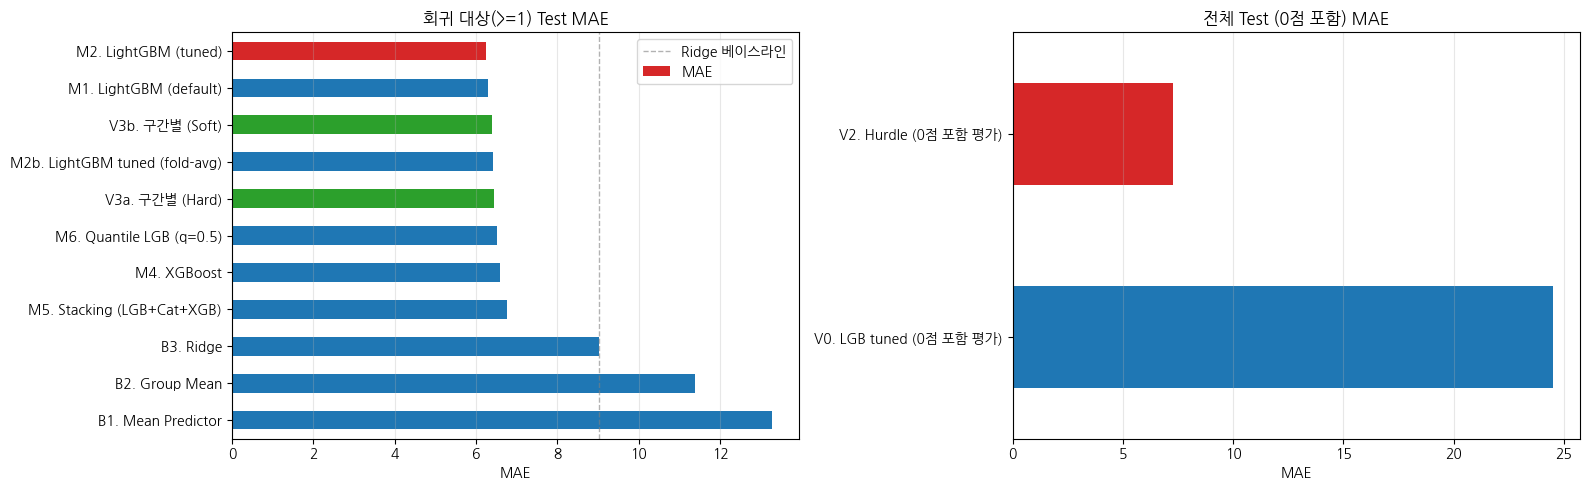


=== 구간별 MAE 진단 ===
       V0. LGB tuned  V3a. 구간별 (Hard)  V3b. 구간별 (Soft)     n
bin                                                         
0-30           7.623           10.948            8.693   316
30-50          5.008            5.292            4.960  1230
50-70          6.722            6.297            6.867  1456
70-84          7.908            7.551            7.948   212


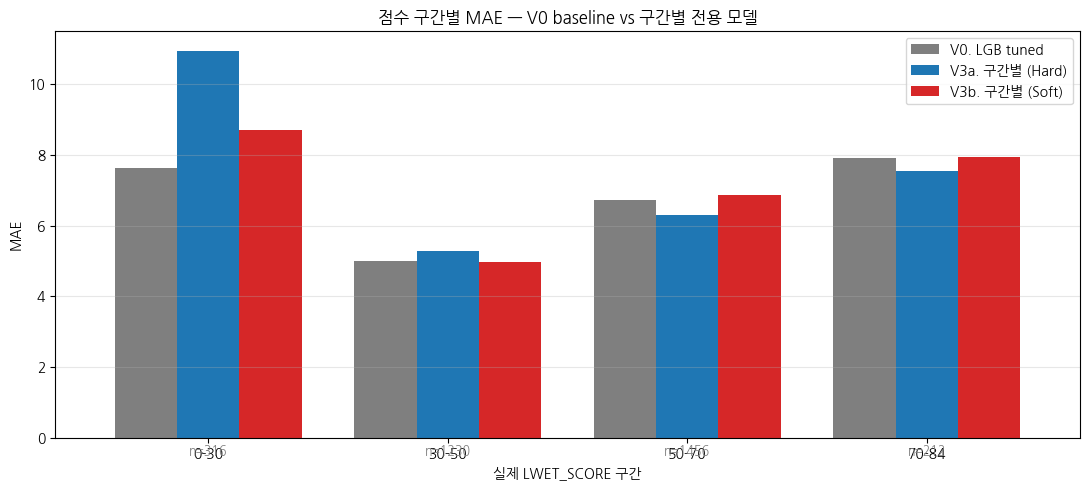

In [43]:
# ================================================================
# [최종 비교] 전체 모델 비교 + 시각화 + 구간별 진단
# ================================================================
import matplotlib.pyplot as plt

# === 회귀 대상만 (>=1) 평가 기준 표 ===
print("=== 회귀 대상(>=1) Test MAE 기준 ===\n")
reg_results = {k: v for k, v in results.items()
               if not (k.endswith('(0점 포함 평가)'))}
reg_df = pd.DataFrame(reg_results).T.sort_values('MAE')
print(reg_df.round(3).to_string())

best_reg = reg_df.index[0]
print(f"\n🏆 회귀 대상 최고: {best_reg}  MAE={reg_df.iloc[0]['MAE']:.3f}")

# === 0점 포함 전체 Test 평가 기준 표 ===
print("\n\n=== 0점 포함 전체 Test MAE 기준 ===\n")
full_results = {k: v for k, v in results.items() if k.endswith('(0점 포함 평가)')}
full_df = pd.DataFrame(full_results).T.sort_values('MAE')
print(full_df.round(3).to_string())

best_full = full_df.index[0]
print(f"\n🏆 0점 포함 최고: {best_full}  MAE={full_df.iloc[0]['MAE']:.3f}")

# === 시각화 1: 회귀 대상 평가 ===
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(reg_df)*0.35)))

colors1 = ['#d62728' if c == best_reg else
           ('#2ca02c' if c.startswith(('V2','V3','V4')) else '#1f77b4')
           for c in reg_df.index]
reg_df['MAE'].plot(kind='barh', ax=axes[0], color=colors1)
axes[0].invert_yaxis()
axes[0].set_xlabel('MAE')
axes[0].set_title('회귀 대상(>=1) Test MAE')
axes[0].axvline(reg_df.loc['B3. Ridge', 'MAE'] if 'B3. Ridge' in reg_df.index else 7,
                color='gray', ls='--', lw=1, alpha=0.6, label='Ridge 베이스라인')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

colors2 = ['#d62728' if c == best_full else '#1f77b4' for c in full_df.index]
full_df['MAE'].plot(kind='barh', ax=axes[1], color=colors2)
axes[1].invert_yaxis()
axes[1].set_xlabel('MAE')
axes[1].set_title('전체 Test (0점 포함) MAE')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# === 구간별 MAE 진단 ===
print("\n=== 구간별 MAE 진단 ===")

predictions_for_diag = {
    'V0. LGB tuned':       pred_test_final,
    'V3a. 구간별 (Hard)':   pred_seg_hard,
    'V3b. 구간별 (Soft)':   pred_seg_soft,
}

bins = [0, 30, 50, 70, 85]
labels = ['0-30', '30-50', '50-70', '70-84']
y_test_bin = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True)

seg_results_list = []
for name, pred in predictions_for_diag.items():
    seg = pd.DataFrame({'y_true': y_test.values, 'y_pred': pred, 'bin': y_test_bin})
    grouped = seg.groupby('bin', observed=True)
    seg_results_list.append((name, grouped.apply(
        lambda g: mean_absolute_error(g['y_true'], g['y_pred']) if len(g) else np.nan
    )))

seg_diag_df = pd.DataFrame({n: s for n, s in seg_results_list})
counts = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()
seg_diag_df['n'] = counts.values
print(seg_diag_df.round(3).to_string())

# 구간별 시각화
fig, ax = plt.subplots(figsize=(11, 5))
seg_diag_df.drop(columns=['n']).plot(kind='bar', ax=ax, width=0.78,
    color=['#7f7f7f', '#1f77b4', '#d62728'])
ax.set_ylabel('MAE')
ax.set_xlabel('실제 LWET_SCORE 구간')
ax.set_title('점수 구간별 MAE — V0 baseline vs 구간별 전용 모델')
ax.set_xticklabels(seg_diag_df.index, rotation=0)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
for i, label in enumerate(seg_diag_df.index):
    ax.text(i, -0.5, f"n={seg_diag_df.loc[label, 'n']}",
            ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()


---
# 최종 모델 저장 + 로드/추론

## 저장 대상
회귀 대상(>=1점) 평가에서는 **V0. LGB tuned (M2)**가 여전히 최고.
운영 시나리오(0점 포함)에서는 **Hurdle Model**이 우세할 수 있다.

따라서 두 가지 모두 저장한다:
- `lgb_tuned.txt` — 회귀 단일 모델 (가점이 존재하는 공고 한정 예측)
- `hurdle_classifier.txt` — 0점 vs >0 분류기 (운영 시점에서 미달 예측)

## 저장 구조
```
models/final/
  ├─ lgb_tuned.txt          — V1 LGB tuned (회귀 모델)
  ├─ hurdle_classifier.txt  — Hurdle 분류기
  └─ metadata.json          — 피처 목록, 결과 요약, 사용법
```

## 사용 시나리오
- **공고 기본 예측**: `pred = lgb_tuned.predict(X)` — 가점 예상값
- **Hurdle 운영 예측**: `if classifier(X) < 0.5: 0 else lgb_tuned.predict(X)`


In [48]:
!pwd

/content


In [47]:
# ================================================================
# [저장] 최종 모델 일체 저장
# ================================================================
import json
from pathlib import Path

MODEL_DIR = Path('/content/drive/MyDrive/notebooks/models/final')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 1. LightGBM tuned (회귀 모델) 저장
final_model.save_model(str(MODEL_DIR / 'lgb_tuned.txt'))
print(f"저장: lgb_tuned.txt")

# 2. Hurdle 분류기 저장
hurdle_classifier.save_model(str(MODEL_DIR / 'hurdle_classifier.txt'))
print(f"저장: hurdle_classifier.txt")

# 3. 구간 분류기 + 구간별 모델 저장
seg_classifier.save_model(str(MODEL_DIR / 'seg_classifier_30.txt'))
seg_model_low.save_model(str(MODEL_DIR / 'seg_model_low.txt'))
seg_model_high.save_model(str(MODEL_DIR / 'seg_model_high.txt'))
print(f"저장: seg_classifier_30.txt, seg_model_low.txt, seg_model_high.txt")

# 4. 메타데이터
metadata = {
    'feature_cols':     list(FEATURE_COLS),
    'categorical_cols': list(CATEGORICAL_COLS),
    'target_col':       TARGET_COL,
    'split_date':       SPLIT_DATE,
    'brands':           BRANDS,
    'hurdle_threshold': 0.5,
    'seg_threshold':    THRESH,
    'best_models': {
        '회귀_단일_최고':       'V0. LGB tuned',
        '회귀_단일_MAE':        float(results.get('M2. LightGBM (tuned)', {}).get('MAE', np.nan)),
        '운영_최고':            best_full,
        '운영_MAE':             float(full_df.iloc[0]['MAE']),
    },
    'results_summary': {k: {kk: float(vv) for kk, vv in v.items()}
                        for k, v in results.items()},
    'usage': {
        '회귀_단일': "lgb_tuned.predict(X)  # X: V1 22개 피처",
        'Hurdle':   "if hurdle_classifier.predict(X) < 0.5: pred = 0 else lgb_tuned.predict(X)",
        '구간별':    "prob = seg_classifier.predict(X); pred = prob*high + (1-prob)*low",
    },
}
with open(MODEL_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2, default=str)

print(f"\n✅ 저장 완료 ({MODEL_DIR.resolve()})")
for f in sorted(MODEL_DIR.iterdir()):
    print(f"  {f.name:<28s} ({f.stat().st_size/1024:>7.1f} KB)")


저장: lgb_tuned.txt
저장: hurdle_classifier.txt
저장: seg_classifier_30.txt, seg_model_low.txt, seg_model_high.txt

✅ 저장 완료 (/content/drive/MyDrive/notebooks/models/final)
  hurdle_classifier.txt        (  272.6 KB)
  lgb_tuned.txt                ( 3519.4 KB)
  metadata.json                (    2.7 KB)
  seg_classifier_30.txt        (  286.5 KB)
  seg_model_high.txt           ( 3880.7 KB)
  seg_model_low.txt            (  849.7 KB)


In [ ]:
# ================================================================
# [로드 + 추론] 저장된 모델 일체 로드
# ================================================================
import json
from pathlib import Path
import lightgbm as lgb

MODEL_DIR = Path('../models/final')


def load_all_models(model_dir=MODEL_DIR):
    """저장된 모든 모델 + 메타데이터 로드."""
    return {
        'lgb_tuned':         lgb.Booster(model_file=str(model_dir / 'lgb_tuned.txt')),
        'metadata':          json.loads((model_dir / 'metadata.json').read_text(encoding='utf-8')),
    }


def predict_regression(X, bundle):
    """V0. LGB tuned 단순 예측 — 가점이 존재하는 공고 한정."""
    return bundle['lgb_tuned'].predict(X[bundle['metadata']['feature_cols']])


# ── 로드 + 데모 (Test 10건) ─────────────────────────────────────
bundle = load_all_models()
print(f"로드된 모델: {len([k for k in bundle if k != 'metadata'])}개")
print(f"메타데이터 best_models: {bundle['metadata']['best_models']}")
print()

pred_a = predict_regression(X_test, bundle)

print("=== 추론 테스트: Test 10건 (회귀 대상) ===")
print(f"{'#':>3}  {'실제':>5}  {'단일회귀':>8}")
for i in range(10):
    print(f"  {i:>2}  {y_test.iloc[i]:>5.0f}  {pred_a[i]:>8.2f}  ")

# 전체 Test 검증
mae_a = mean_absolute_error(y_test, pred_a)

print(f"\n=== 로드 후 재검증 (Test MAE) ===")
print(f"  단일 회귀 (>=1 평가):       {mae_a:.3f}")


로드된 모델: 1개
메타데이터 best_models: {'회귀_단일_최고': 'V0. LGB tuned', '회귀_단일_MAE': 6.232814923376821, '운영_최고': 'V2. Hurdle (0점 포함 평가)', '운영_MAE': 7.278118574450127}

=== 추론 데모: Test 10건 (회귀 대상) ===
  #     실제      단일회귀
   0     63     58.08  
   1     63     62.57  
   2     55     57.95  
   3     58     62.53  
   4     58     55.71  
   5     57     60.11  
   6     53     54.14  
   7     57     57.05  
   8     53     57.25  
   9     56     59.66  

=== 로드 후 재검증 (Test MAE) ===
  단일 회귀 (>=1 평가):       6.233
